# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 16    |  |
| :-------------|:-------------|
| Wolf Peutz| 6436102 |
| Victor Scholten | 6434789 |
| Tahlia van den Berg| 6399991 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Wolf', 'Victor','Tahlia']


## Opdracht 1: Planning.

| Planning Groep: 16     |Tijdstip / Tijdspanne  |
|---|---|
| kalibreren sensor | 11:30 |
| testen meetopstelling | 12:00 |
| Iteratie 0 | 14:15 |
| Iteratie 1+ | 15:30 |
| volledig inleveren | 17:30 |
| groep aanwezig 1| 11:00 |
| groep aanwezig 2| 13:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [16]
<img src="kalibratiefoto.png" width="400">

Fit parameters: a=0.03665438650813888, b=-6.107393055219614


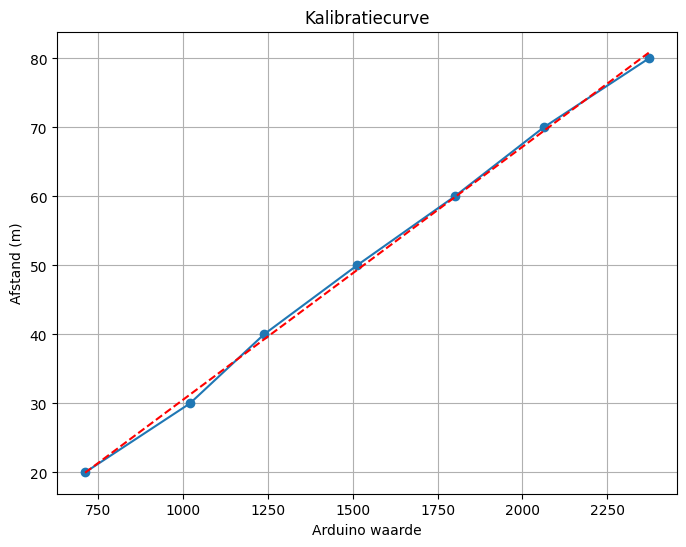

   Afstand  Arduino
0       20      711
1       30     1020
2       40     1238
3       50     1512
4       60     1800
5       70     2062
6       80     2372


In [3]:
from scipy.optimize import curve_fit
# verwerk hier jullie kalibratiemetingen
afstanden = np.array([20,30, 40,50, 60,70, 80]) #m
arduinovalue = np.array([711, 1020, 1238,1512, 1800, 2062, 2372])
 #bits
kalibratieData = pd.DataFrame({'Afstand': afstanden, 'Arduino': arduinovalue})

#fit:
def fitfunc(x, a, b):
    return a * x + b
popt, pcov = curve_fit(fitfunc, kalibratieData['Arduino'], kalibratieData['Afstand'])
print(f'Fit parameters: a={popt[0]}, b={popt[1]}')

x_test = np.linspace(min(kalibratieData['Arduino']), max(kalibratieData['Arduino']), 100)
# plot de kalibratiecurve
plt.figure(figsize=(8, 6))
plt.plot(kalibratieData['Arduino'],kalibratieData['Afstand'],  'o-')
plt.plot(x_test, fitfunc(x_test, *popt), 'r--', label='Fit: a={:.2f}, b={:.2f}'.format(*popt))
plt.xlabel('Arduino waarde')  
plt.ylabel('Afstand (m)')
plt.title('Kalibratiecurve') 
plt.grid()
plt.show()
print(kalibratieData)


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  39.99
1   0  30   0  20  40.40
2  40   0  30   0  41.25
3  30   0  20   0  41.18


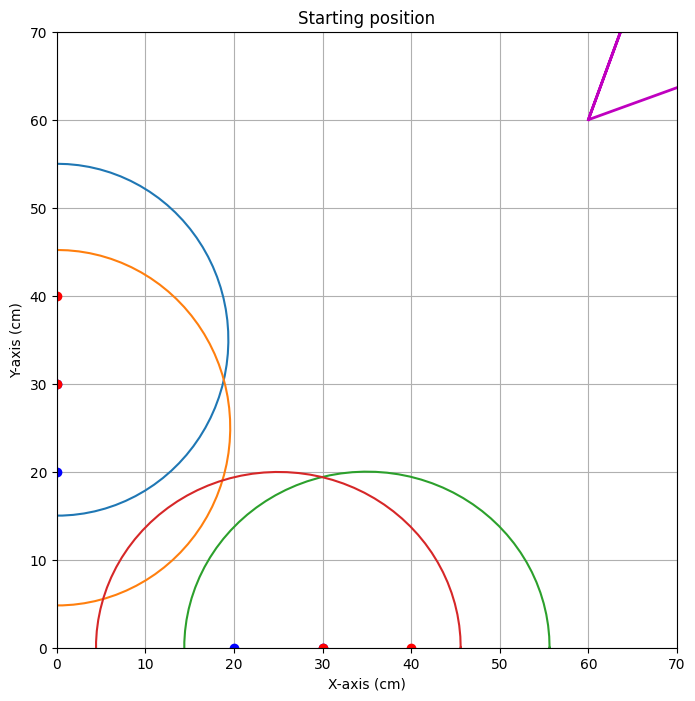


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.250


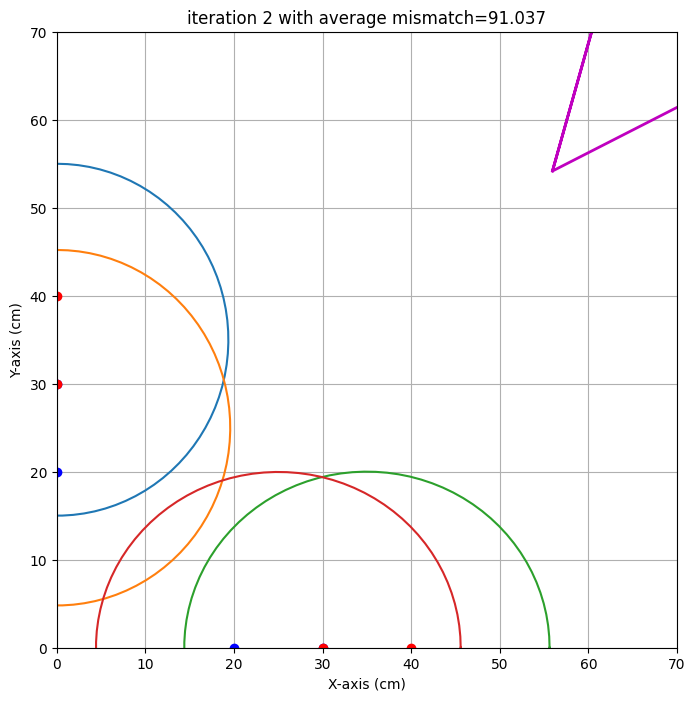

end iteration 2 with average mismatch=91.037


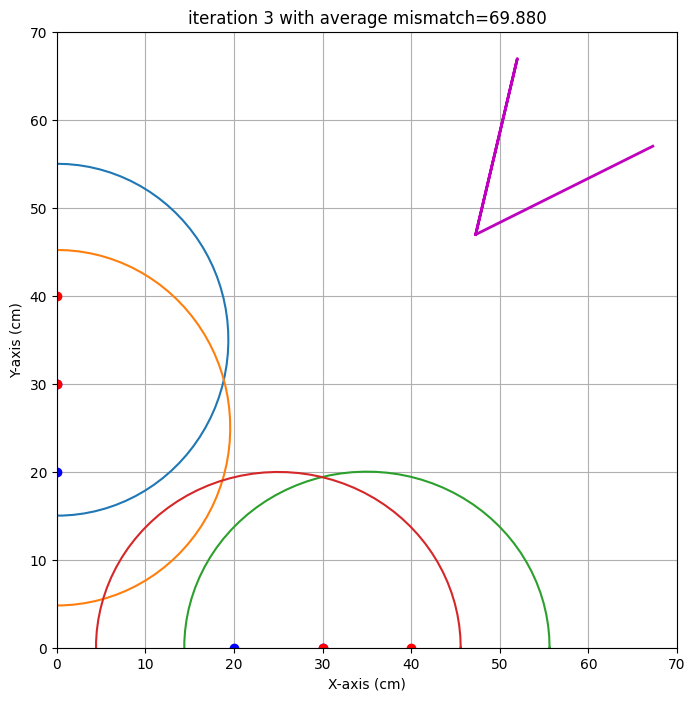

end iteration 3 with average mismatch=69.880


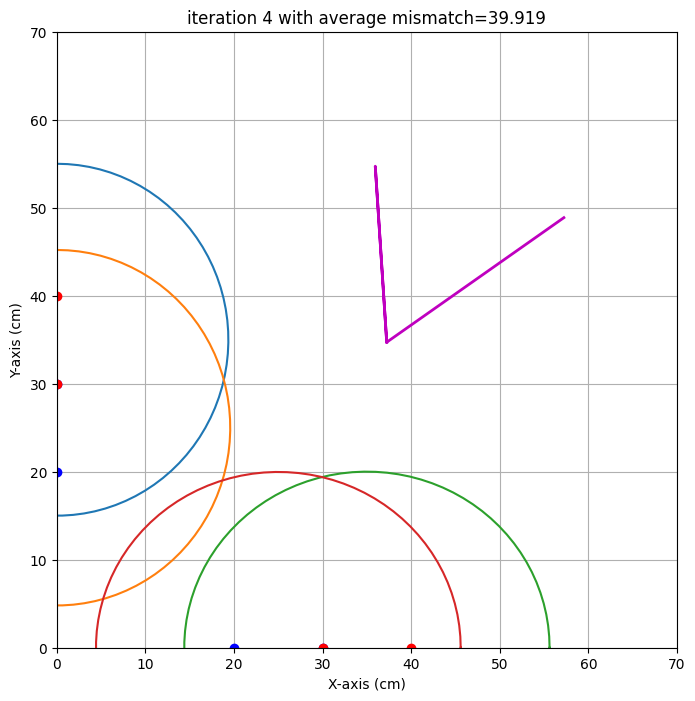

end iteration 4 with average mismatch=39.919


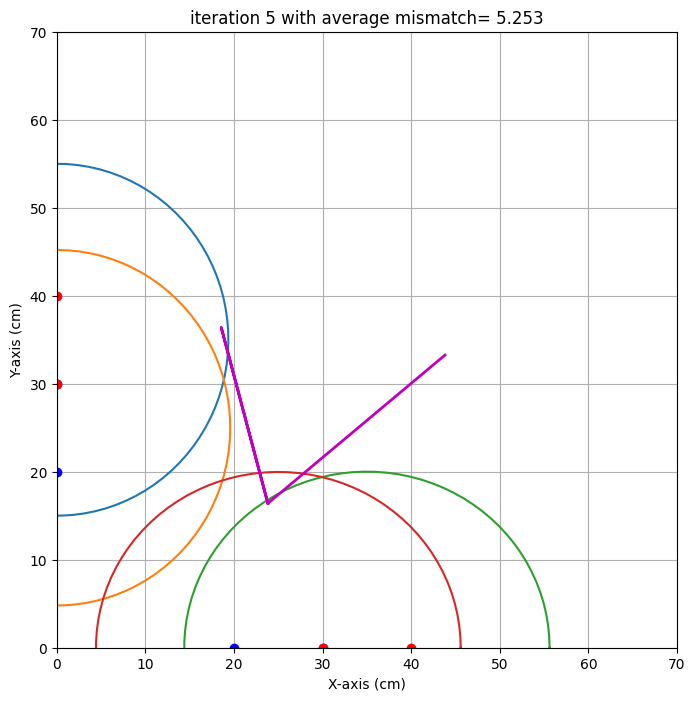

end iteration 5 with average mismatch= 5.253


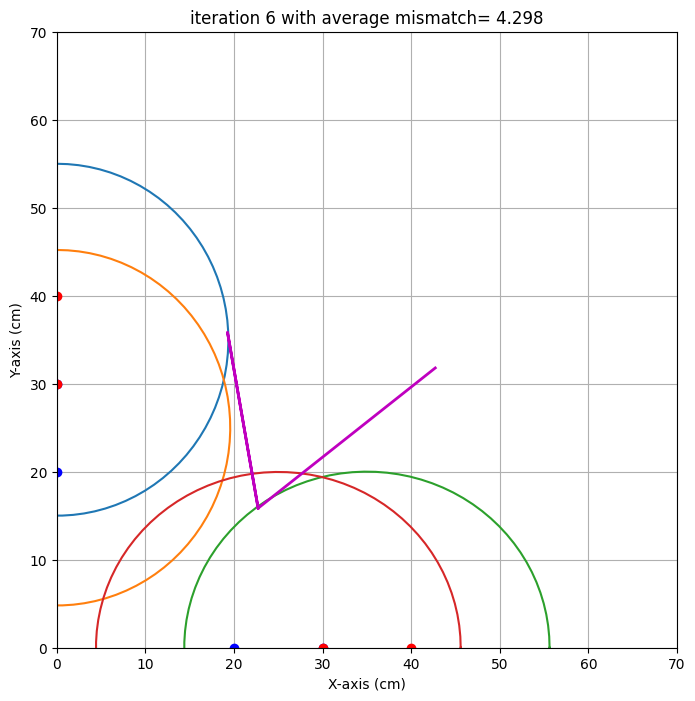

end iteration 6 with average mismatch= 4.298


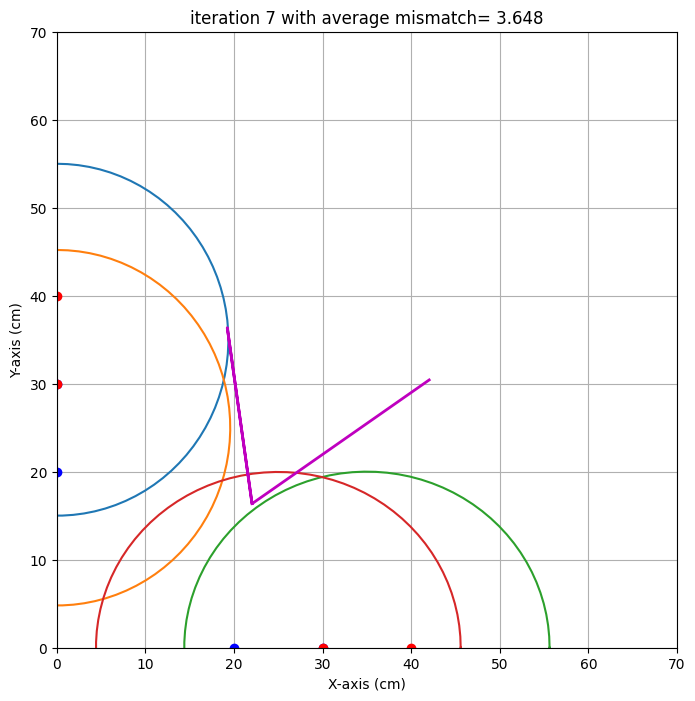

end iteration 7 with average mismatch= 3.648


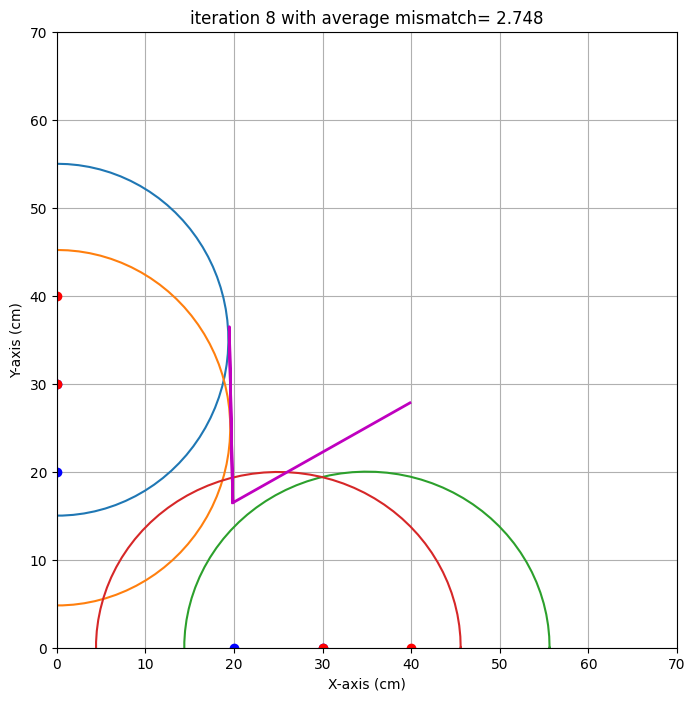

end iteration 8 with average mismatch= 2.748
end iteration 9 with average mismatch= 2.687
end iteration 10 with average mismatch= 2.643
end iteration 11 with average mismatch= 2.609


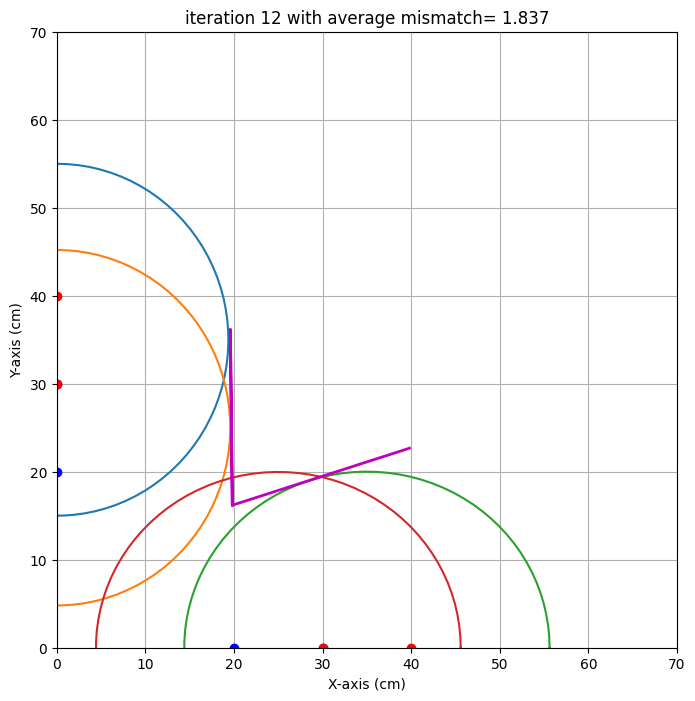

end iteration 12 with average mismatch= 1.837


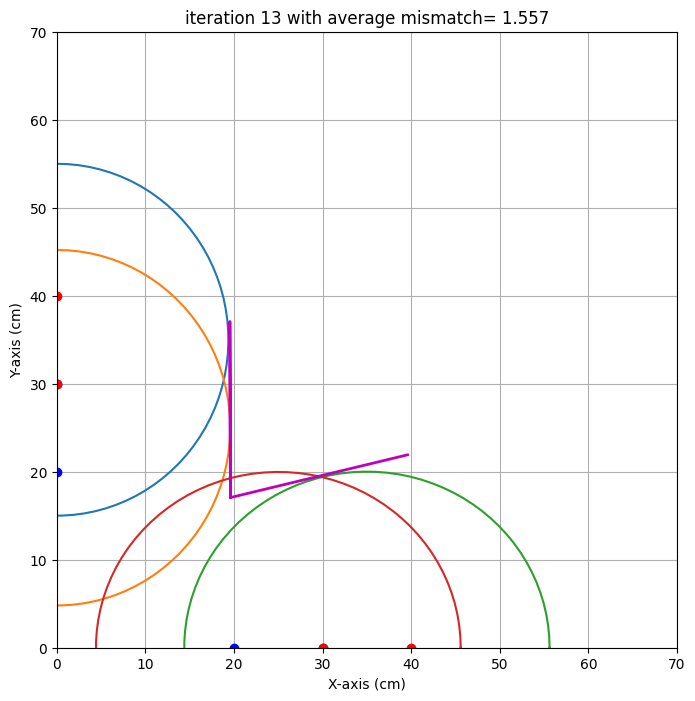

end iteration 13 with average mismatch= 1.557
end iteration 14 with average mismatch= 1.554
end iteration 15 with average mismatch= 1.554
end iteration 16 with average mismatch= 1.554
end iteration 17 with average mismatch= 1.422
end iteration 18 with average mismatch= 1.364


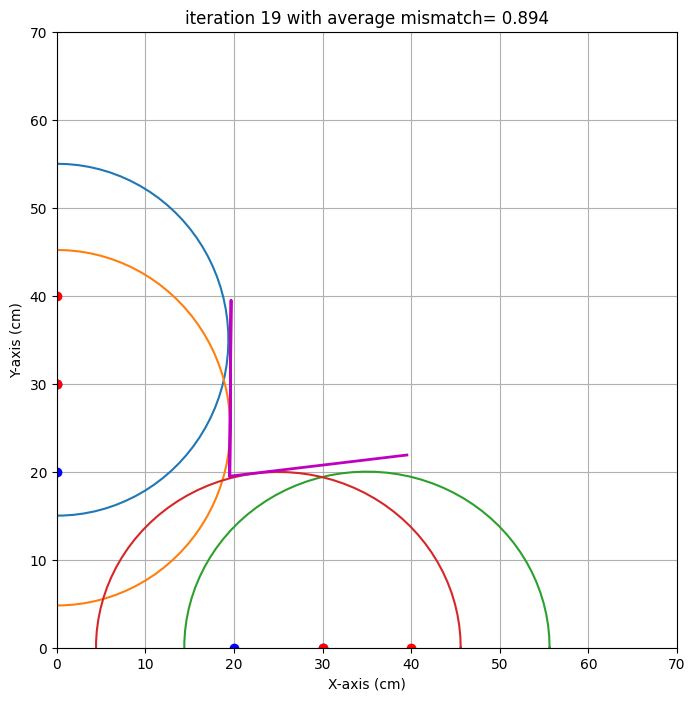

end iteration 19 with average mismatch= 0.894


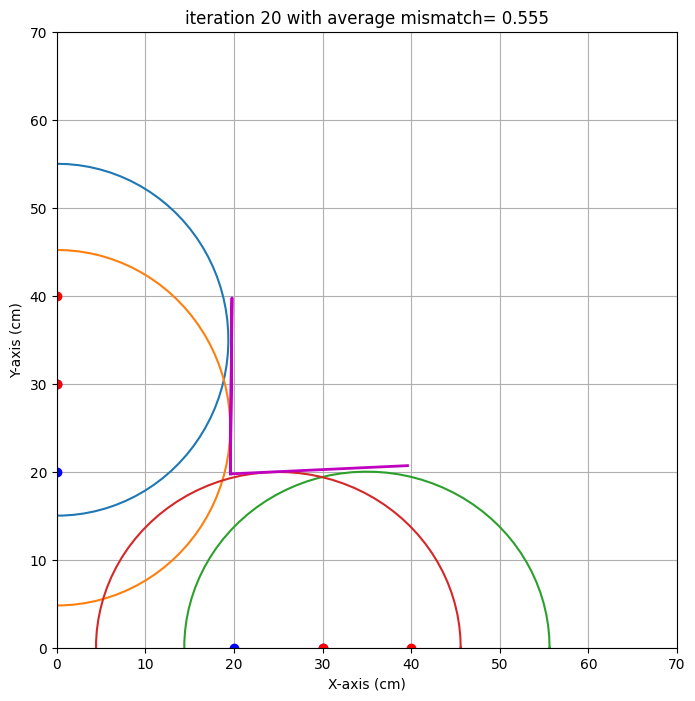

end iteration 20 with average mismatch= 0.555


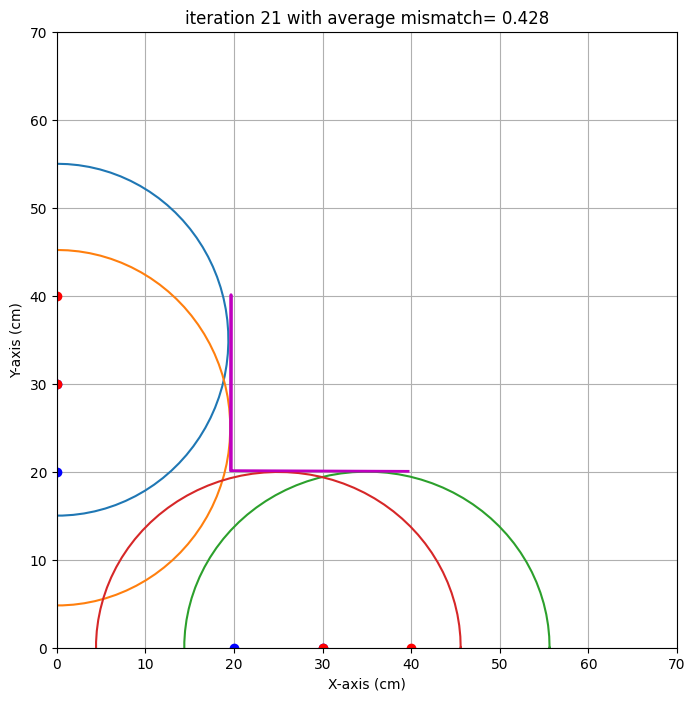

end iteration 21 with average mismatch= 0.428


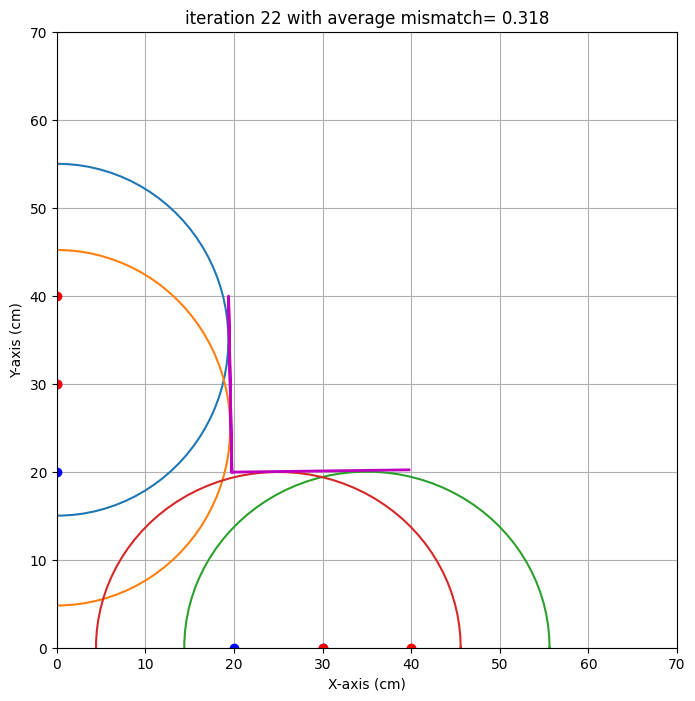

end iteration 22 with average mismatch= 0.318


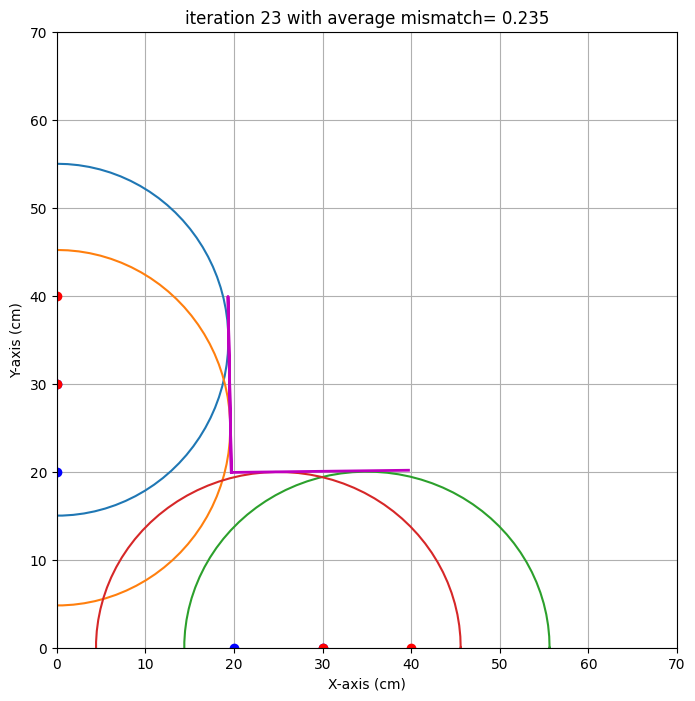

end iteration 23 with average mismatch= 0.235
end iteration 24 with average mismatch= 0.213
end iteration 25 with average mismatch= 0.211
end iteration 26 with average mismatch= 0.211
end iteration 27 with average mismatch= 0.211
end iteration 28 with average mismatch= 0.211
end iteration 29 with average mismatch= 0.211
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.211
###############################################################################
end of iteration  30
Best alpha=   0.69 with uncertainty=   0.00
Best beta =  -1.08 with uncertainty=   0.00
Best x0   =  19.67 with uncertainty=   0.00
Best y0   =  19.90 with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


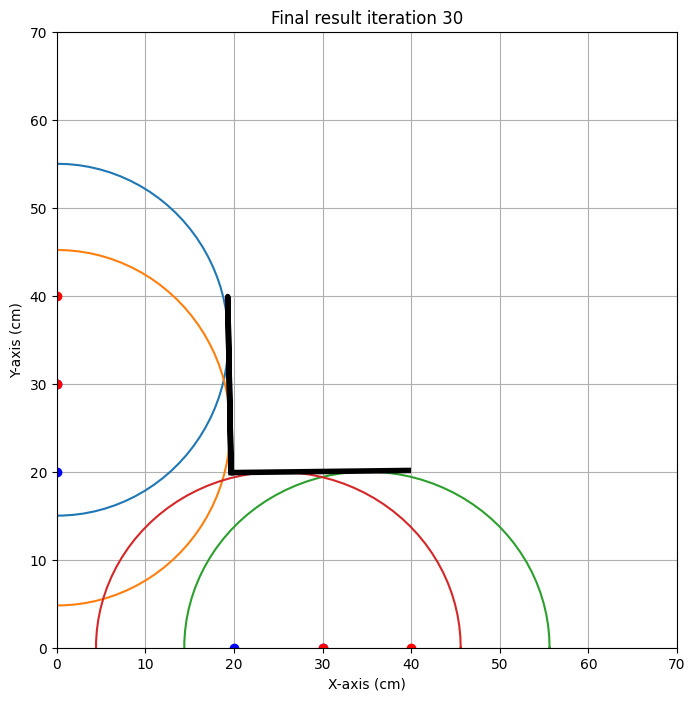

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,39.99],
    [0,30,0,20,40.40],
    #[0,10,0,20,188.77],#ongeldige meting
    [40,0,30,0,41.25],
    [30,0,20,0,41.18]
    #[10,0,20,0,144.28],#ongeldige meting
    #[10,0,0,10,136.37] #ongeldige meting   
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.7 cm met een standaardafwijking van 0.0 cm 
y0: 19.9 cm met een standaardafwijking van 0.0 cm 
alpha: 0.7 graden met een standaardafwijking van 0.0 graad 
beta: -1.1 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Tahlia]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="fototahlia.png" width="400">

#### algoritme [Wolf]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="fotowolf.png" width="400">

#### algoritme [Victor]
Voeg een foto in van het algoritme van het derde groepslid
<img src="fotovictor.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 23,  #cm,
           'y0': 27,  #cm,
           'alpha' : 0,  #zelf aanvullen, graden
           'beta' : 33 #zelf aanvullen}, graden
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={
'Tahlia' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,50,0,35,ongeldig],
    [30,0, 45, 0, 56.6],
    [40,0,25,0,55.9 ],
    [0,70,0,55, 71.4],
    [0,50,0,65, 67.5]
    ]),
       'Wolf' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20,0,0,20, 26.9],
    [40,0,0,40,55.8],
    [60,0,0,60, 87.0],
    #[65,0,0,65, ongeldig],
    [0,65, 0, 60, 77.8]
   #[65, 0, 60,0, ongeldig]
    ])
   #     'naam3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #  #zelf aanvullen
   #  ])
      }
studentNames = ['Tahlia', 'Wolf']


In [8]:
#deze cell is niet van toepassing

# resultaat = dict()
# for studentName in studentNames:
#     print(studentName)
#     resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
#     print(resultaat[studentName])

In [9]:
#deze cell is niet van toepassing

# data ={'Tahlia' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
#     #[0,50,0,35,ongeldig],
#     [30,0, 45, 0, 56.6],
#     [40,0,25,0,55.9 ],
#     [0,70,0,55, 71.4],
#     [0,50,0,65, 67.5]
#     ])}
# studentNames = ['Tahlia']

## Opdracht 7: Evaluatie.

Tahlia
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  45   0  56.6
1  40   0  25   0  55.9
2   0  70   0  55  71.4
3   0  50   0  65  67.5


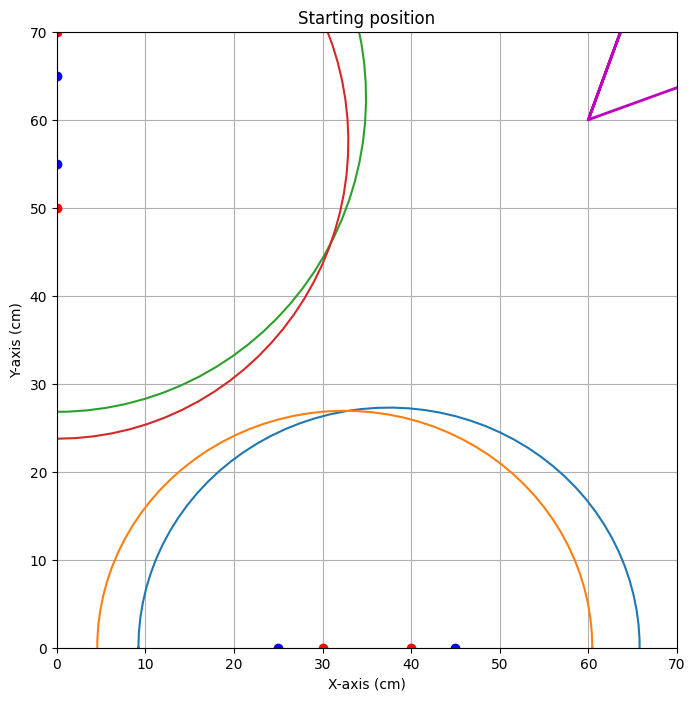


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.333


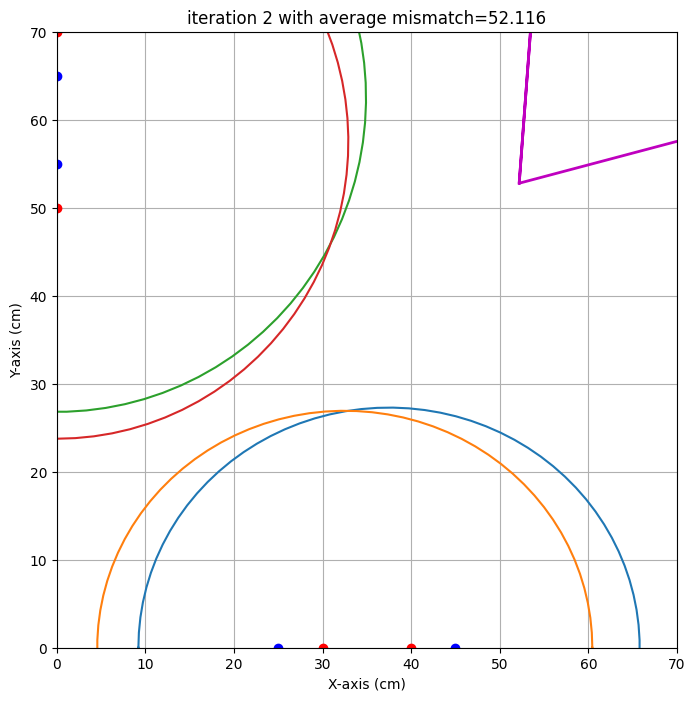

end iteration 2 with average mismatch=52.116


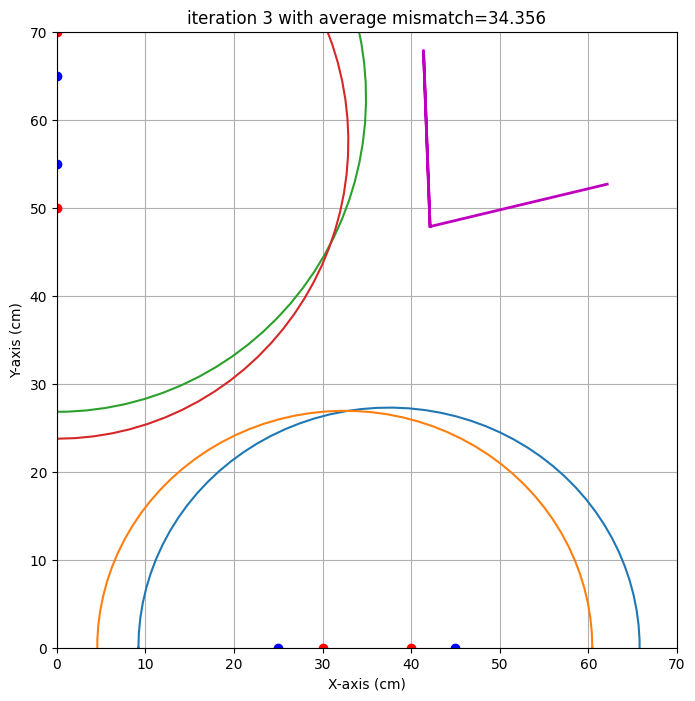

end iteration 3 with average mismatch=34.356


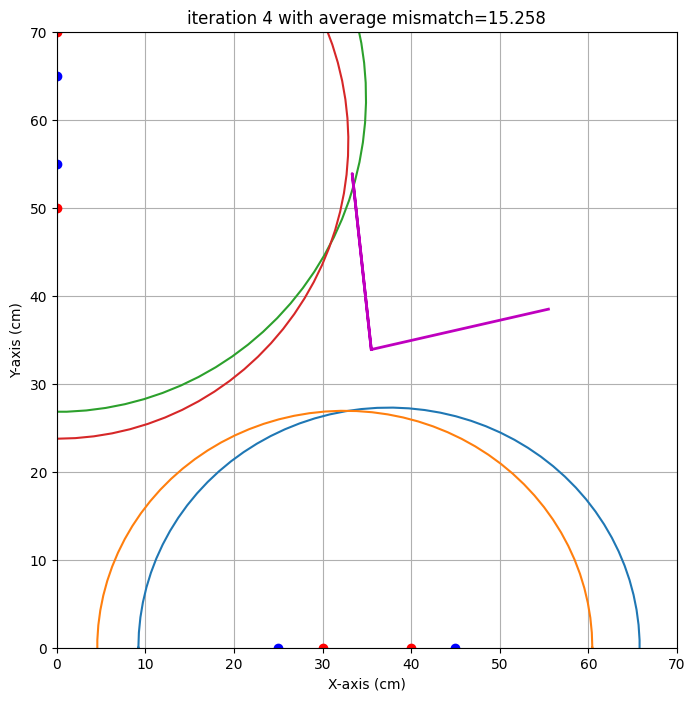

end iteration 4 with average mismatch=15.258


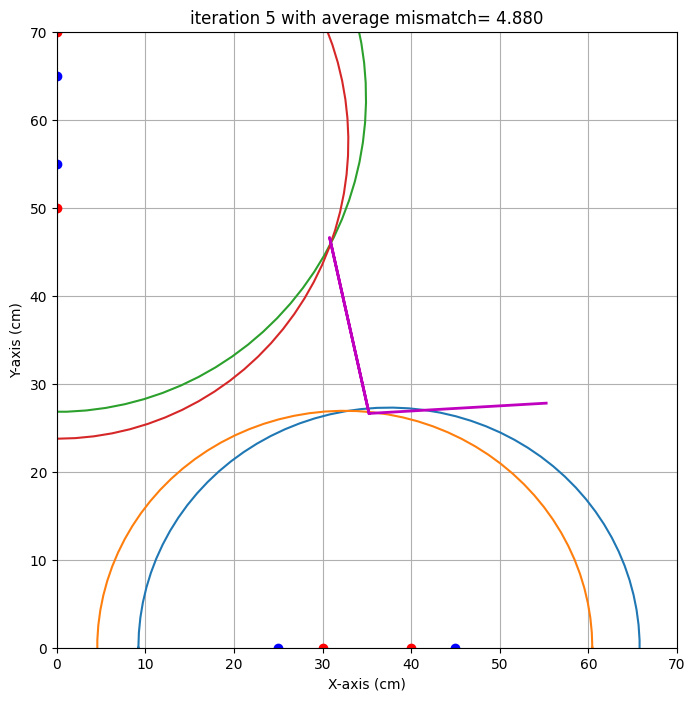

end iteration 5 with average mismatch= 4.880
end iteration 6 with average mismatch= 4.863


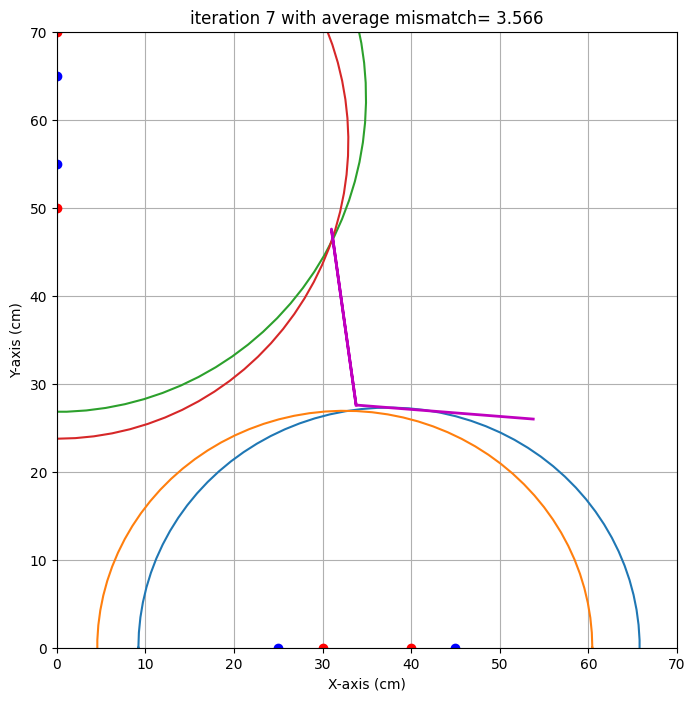

end iteration 7 with average mismatch= 3.566


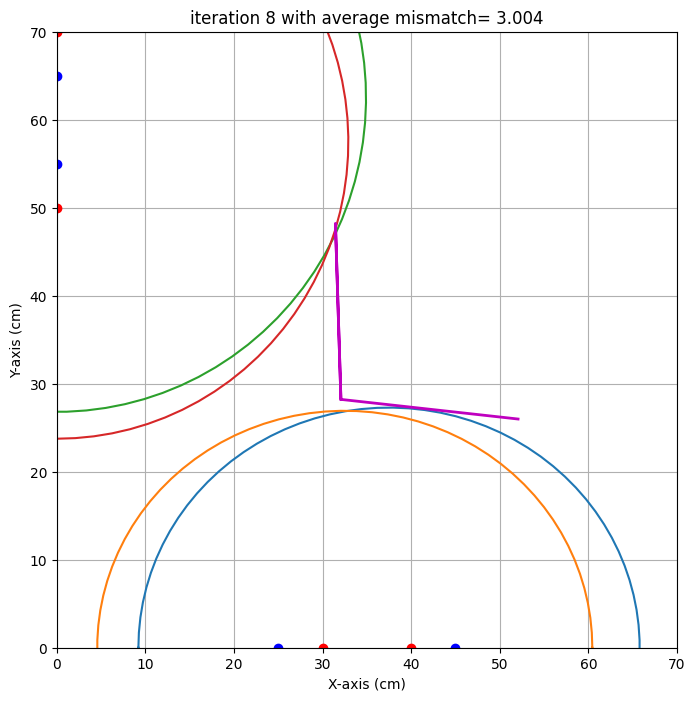

end iteration 8 with average mismatch= 3.004


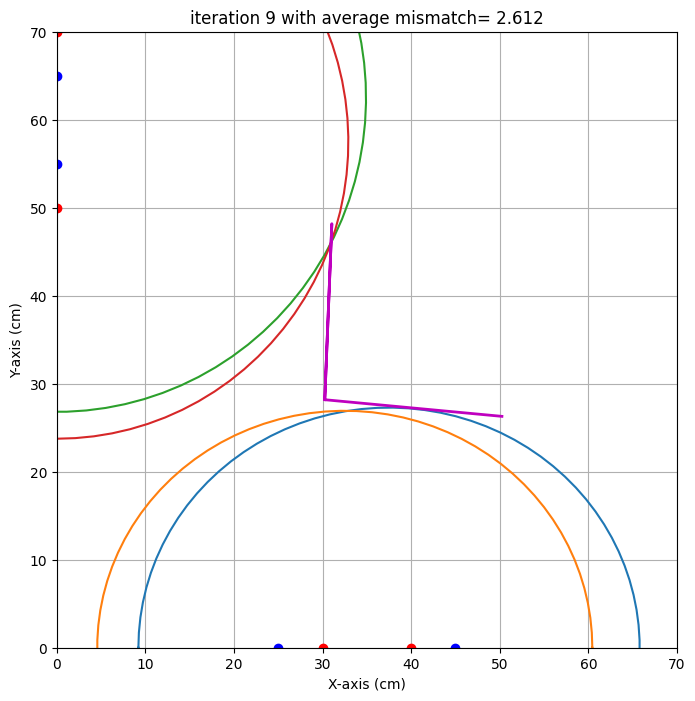

end iteration 9 with average mismatch= 2.612


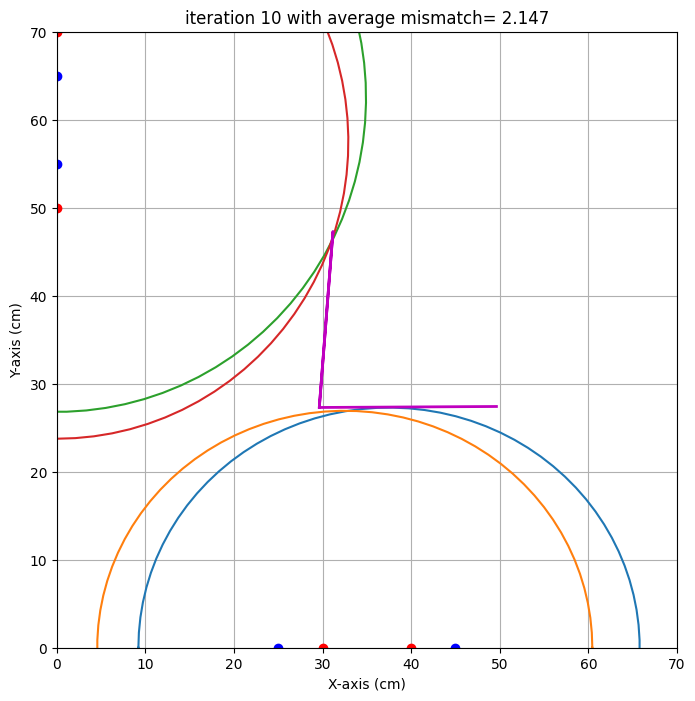

end iteration 10 with average mismatch= 2.147
end iteration 11 with average mismatch= 1.947


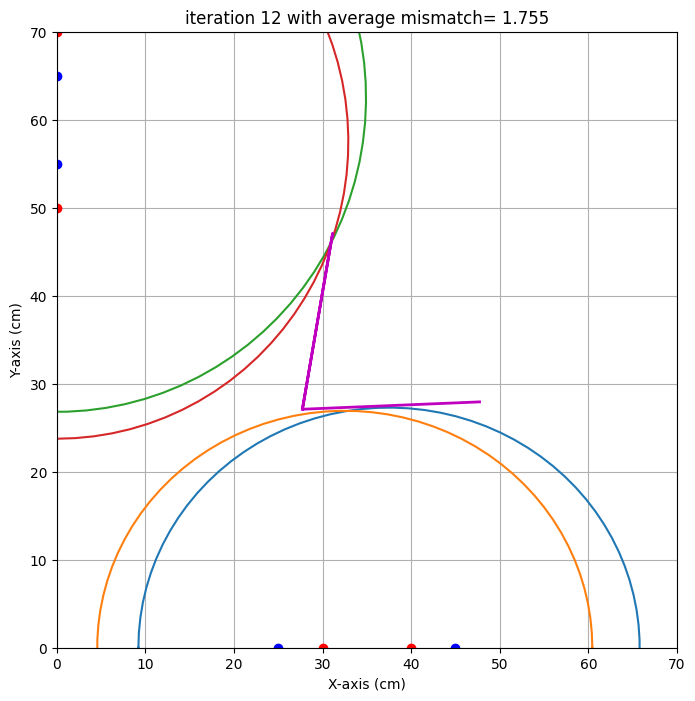

end iteration 12 with average mismatch= 1.755


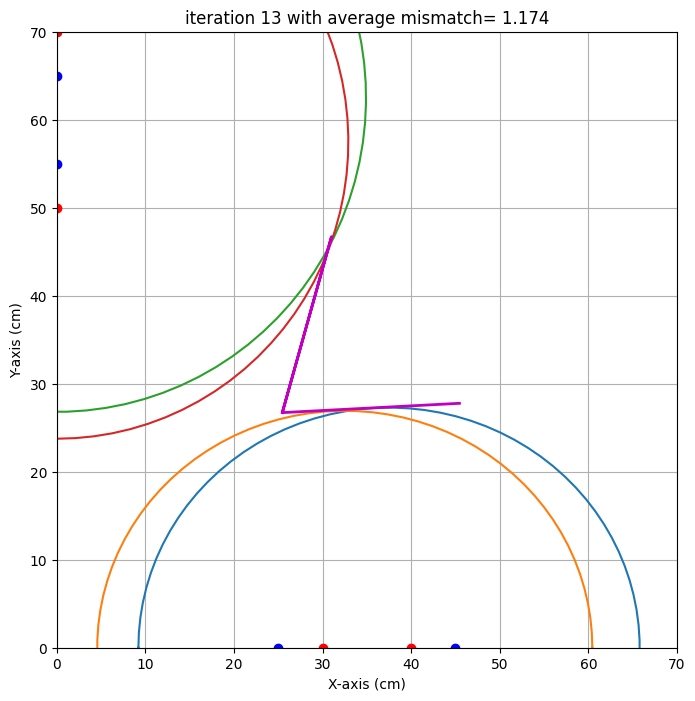

end iteration 13 with average mismatch= 1.174


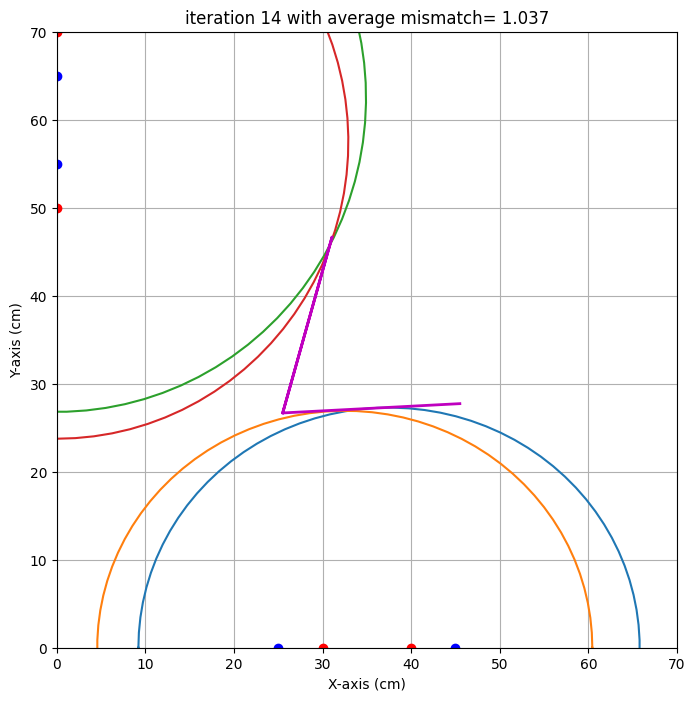

end iteration 14 with average mismatch= 1.037
end iteration 15 with average mismatch= 1.037


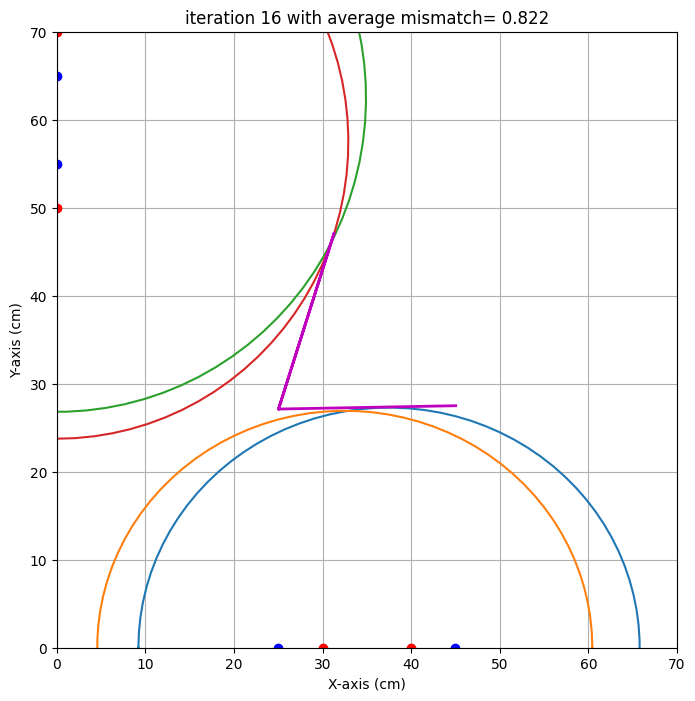

end iteration 16 with average mismatch= 0.822


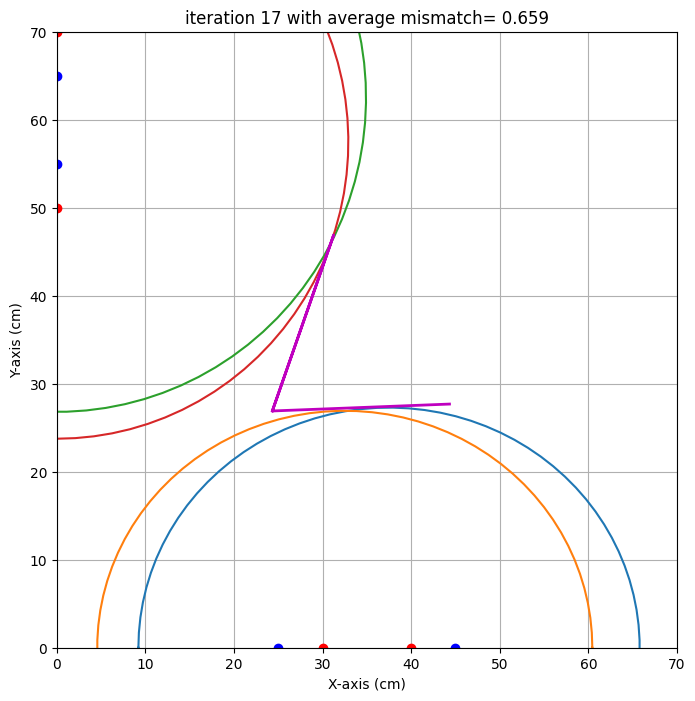

end iteration 17 with average mismatch= 0.659
end iteration 18 with average mismatch= 0.621
end iteration 19 with average mismatch= 0.605
end iteration 20 with average mismatch= 0.600
end iteration 21 with average mismatch= 0.599
end iteration 22 with average mismatch= 0.592
end iteration 23 with average mismatch= 0.571
end iteration 24 with average mismatch= 0.569
end iteration 25 with average mismatch= 0.569
end iteration 26 with average mismatch= 0.569
end iteration 27 with average mismatch= 0.562
end iteration 28 with average mismatch= 0.562
end iteration 29 with average mismatch= 0.562
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.562
###############################################################################
end of iteration  30
Best alpha=   0.75 with uncertainty=   9.46
Best beta =  20.83 with uncertainty=  12.49
Best x0   =  23.76 with uncertainty=   4.38
Best y0   =  2

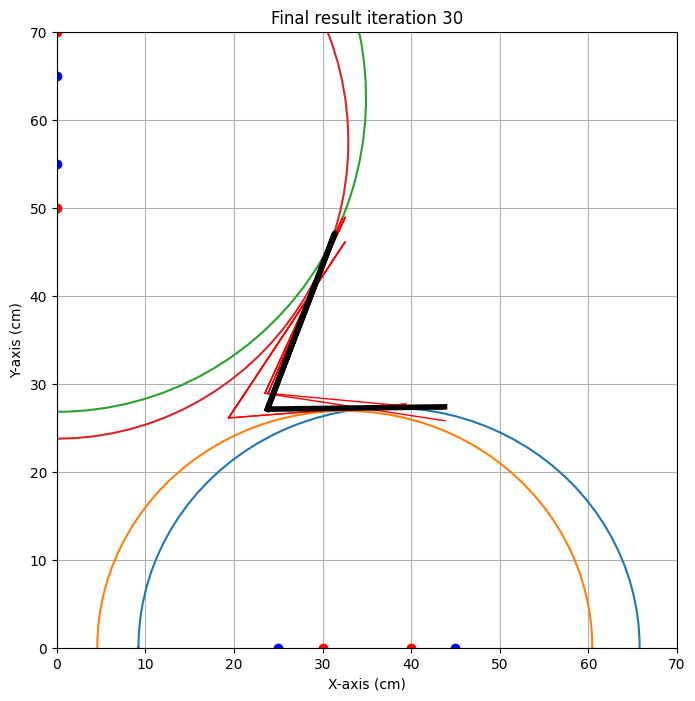

{'alpha': np.float64(0.7453003094258622), 'alpha_eps': np.float64(9.455311206714649), 'beta': np.float64(20.83011468763816), 'beta_eps': np.float64(12.49453298922435), 'x0': np.float64(23.764384504423408), 'x0_eps': np.float64(4.380363411577623), 'y0': np.float64(27.109518470936738), 'y0_eps': np.float64(1.8303115930010172)}
Wolf
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  20   0   0  20  26.9
1  40   0   0  40  55.8
2  60   0   0  60  87.0
3   0  65   0  60  77.8


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


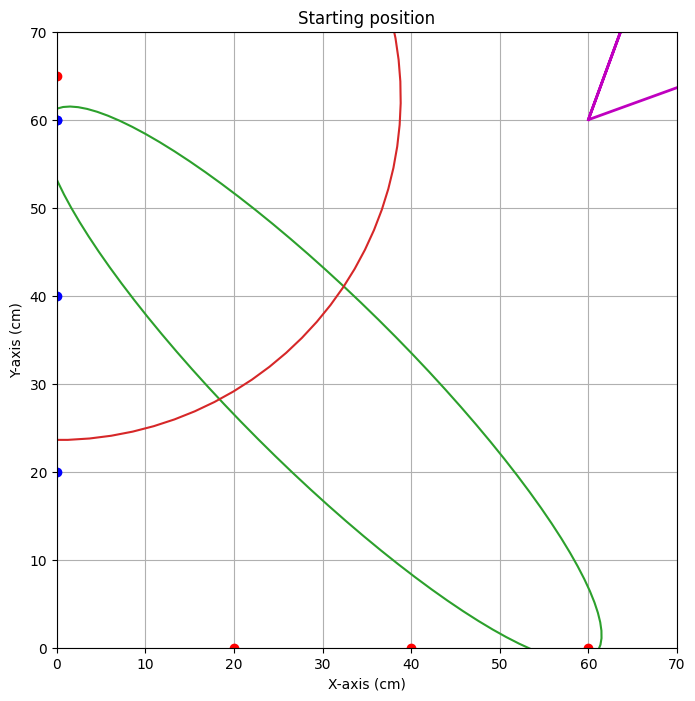


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=71.009


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


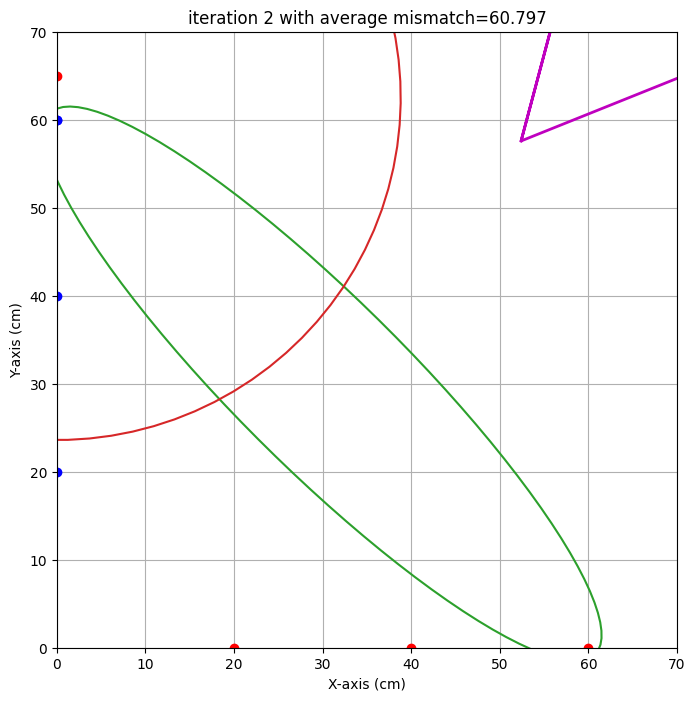

end iteration 2 with average mismatch=60.797


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


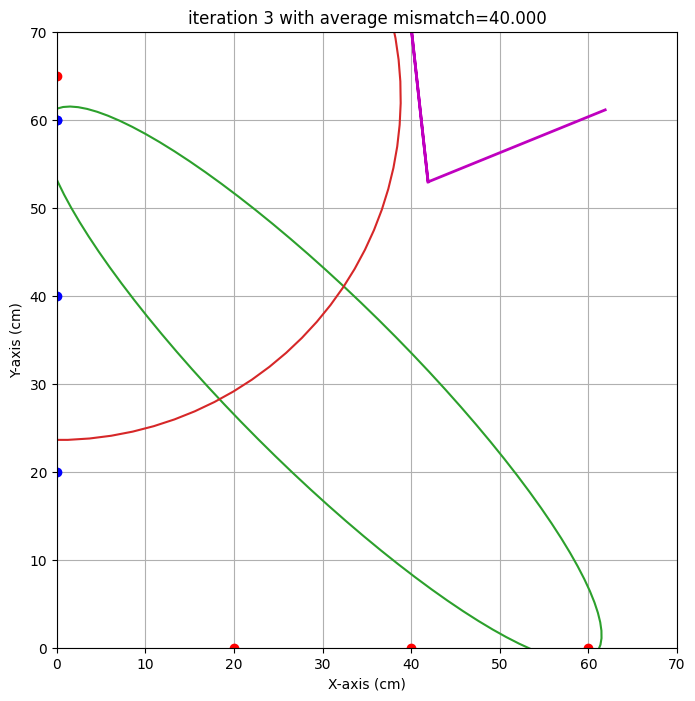

end iteration 3 with average mismatch=40.000


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


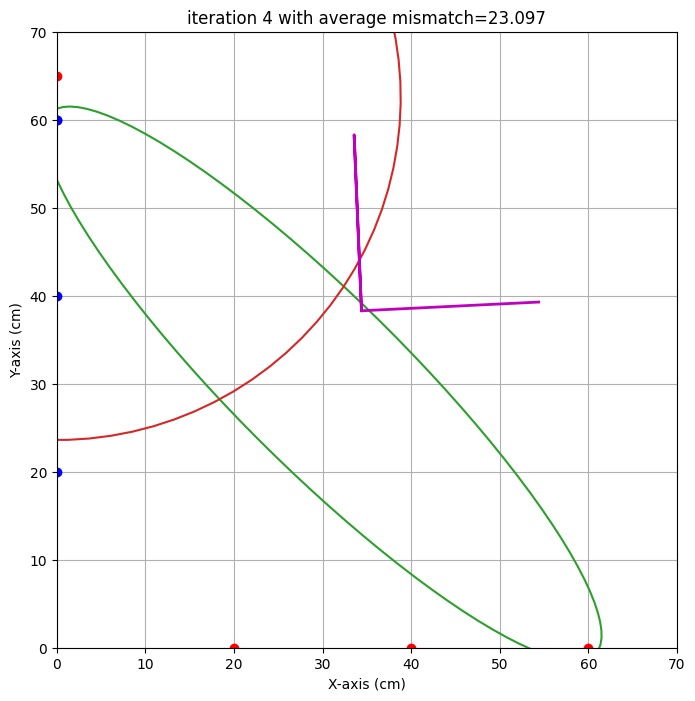

end iteration 4 with average mismatch=23.097


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


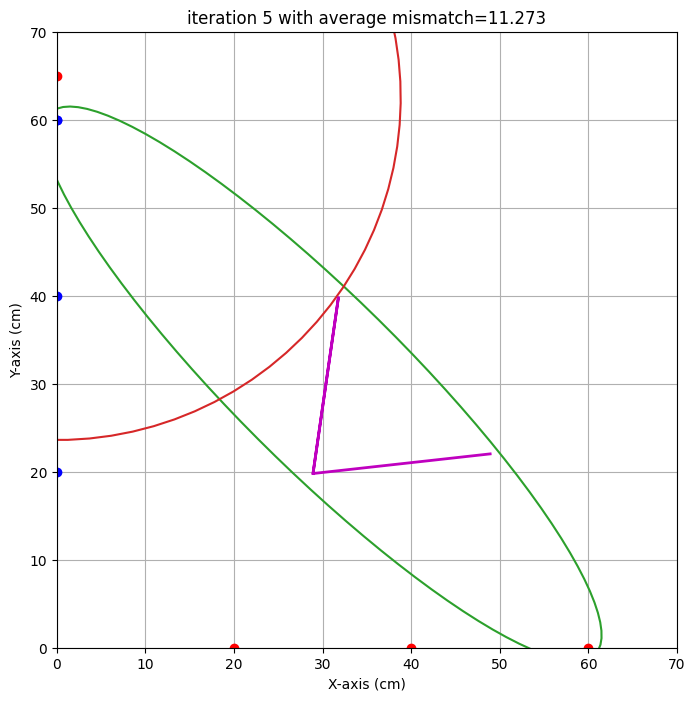

end iteration 5 with average mismatch=11.273


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


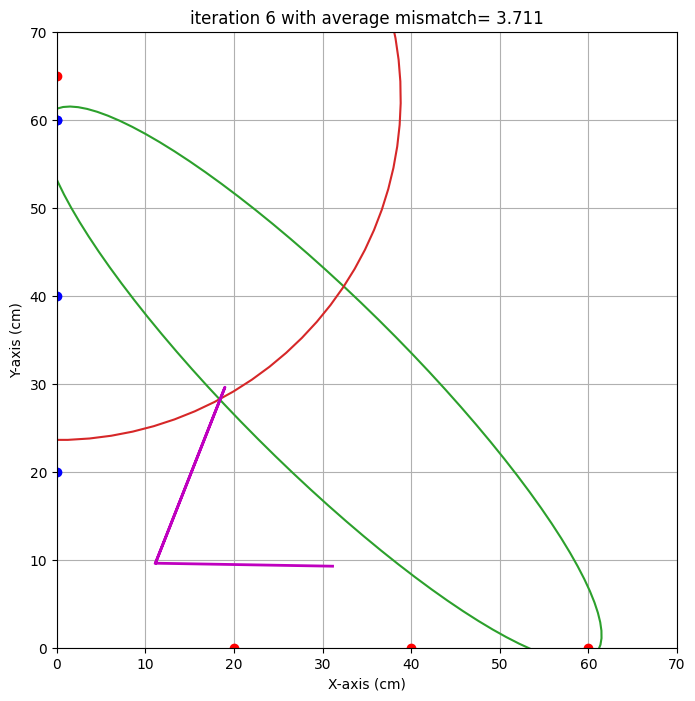

end iteration 6 with average mismatch= 3.711


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


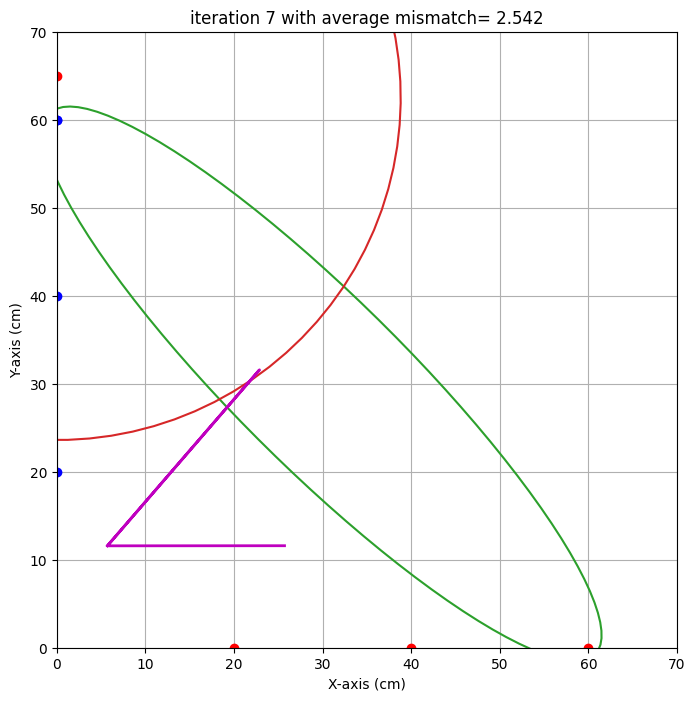

end iteration 7 with average mismatch= 2.542


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


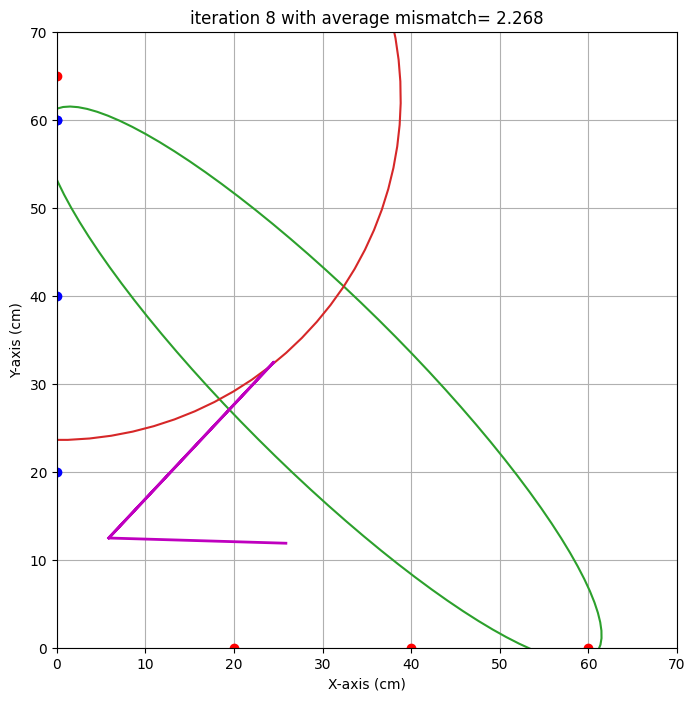

end iteration 8 with average mismatch= 2.268
end iteration 9 with average mismatch= 2.208
end iteration 10 with average mismatch= 2.192
end iteration 11 with average mismatch= 2.191
end iteration 12 with average mismatch= 2.191
end iteration 13 with average mismatch= 2.182
end iteration 14 with average mismatch= 2.182
end iteration 15 with average mismatch= 2.160
end iteration 16 with average mismatch= 2.160
end iteration 17 with average mismatch= 2.160
end iteration 18 with average mismatch= 2.154
end iteration 19 with average mismatch= 2.154
end iteration 20 with average mismatch= 2.154
end iteration 21 with average mismatch= 2.154
end iteration 22 with average mismatch= 2.154
end iteration 23 with average mismatch= 2.154
end iteration 24 with average mismatch= 2.154
end iteration 25 with average mismatch= 2.154
end iteration 26 with average mismatch= 2.154
end iteration 27 with average mismatch= 2.154
end iteration 28 with average mismatch= 2.153
end iteration 29 with average mismat

C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


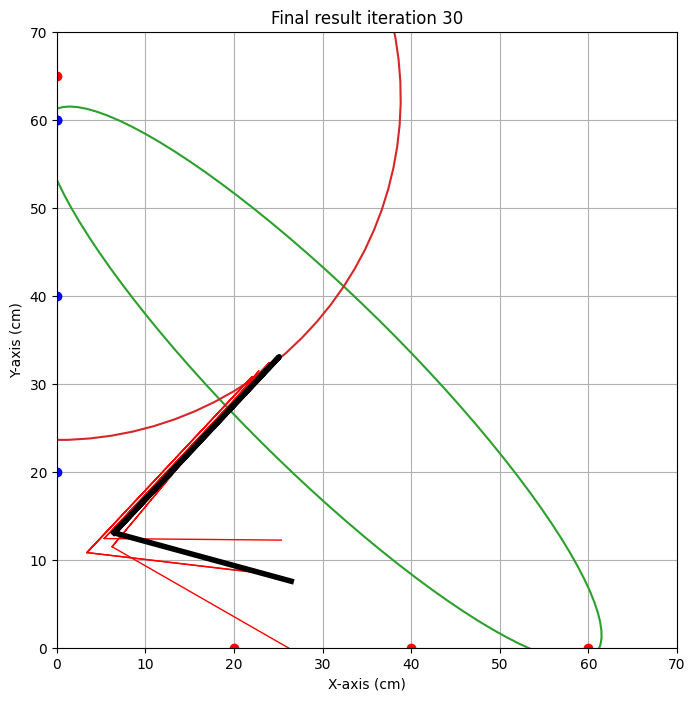

{'alpha': np.float64(-15.378586988436576), 'alpha_eps': np.float64(14.87024844548726), 'beta': np.float64(43.0), 'beta_eps': np.float64(3.3311723267319095), 'x0': np.float64(6.449674606528448), 'x0_eps': np.float64(3.059080766624417), 'y0': np.float64(13.059580683737618), 'y0_eps': np.float64(2.248857483289628)}


In [10]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [11]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.

for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))


Tahlia 
x0 target is : 23.0. Gevonden waarde: 23.8 cm met een standaardafwijking van 4.4 cm 
y0 target is : 27.0. Gevonden waarde: 27.1 cm met een standaardafwijking van 1.8 cm 
alpha target is : 0.0. Gevonden waarde: 0.7 graden met een standaardafwijking van 9.5 graad 
beta target is : 33.0. Gevonden waarde: 20.8 graden met een standaardafwijking van 12.5 graad 

Wolf 
x0 target is : 23.0. Gevonden waarde: 6.4 cm met een standaardafwijking van 3.1 cm 
y0 target is : 27.0. Gevonden waarde: 13.1 cm met een standaardafwijking van 2.2 cm 
alpha target is : 0.0. Gevonden waarde: -15.4 graden met een standaardafwijking van 14.9 graad 
beta target is : 33.0. Gevonden waarde: 43.0 graden met een standaardafwijking van 3.3 graad 



## Opdracht 8: Iteratie1+.tijd: 15:05
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](verbeterdalgoritme_iteratie+1.png)


In [12]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  35  59.30
1  30   0  45   0  58.45
2   0  40   0  55  60.45
3  35   0  50   0  60.15


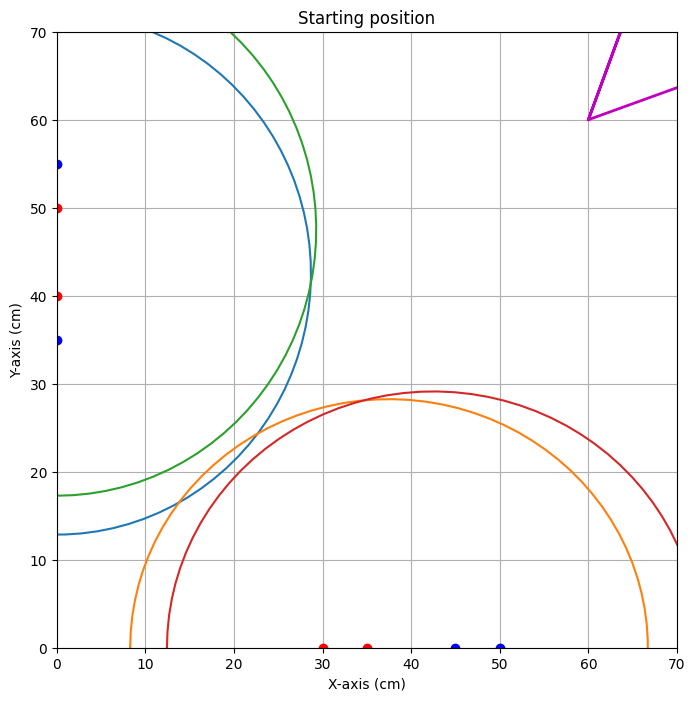


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.848


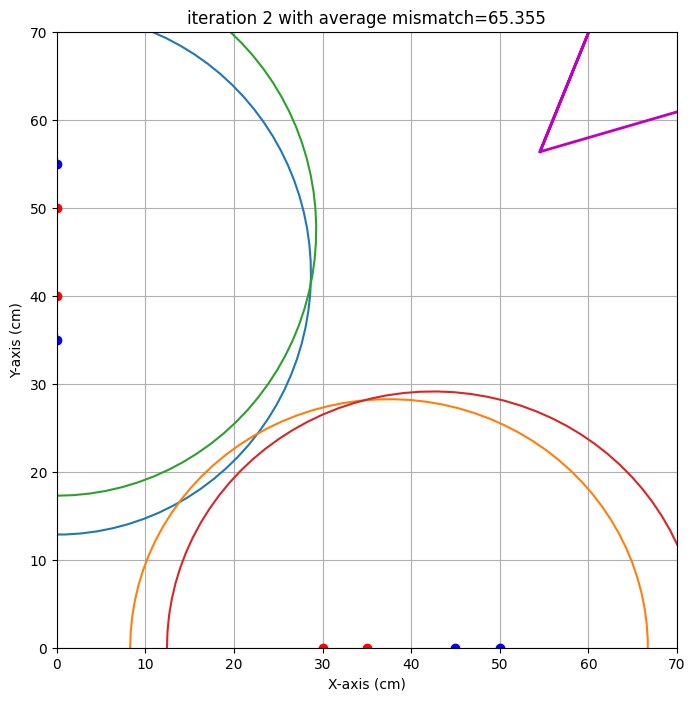

end iteration 2 with average mismatch=65.355


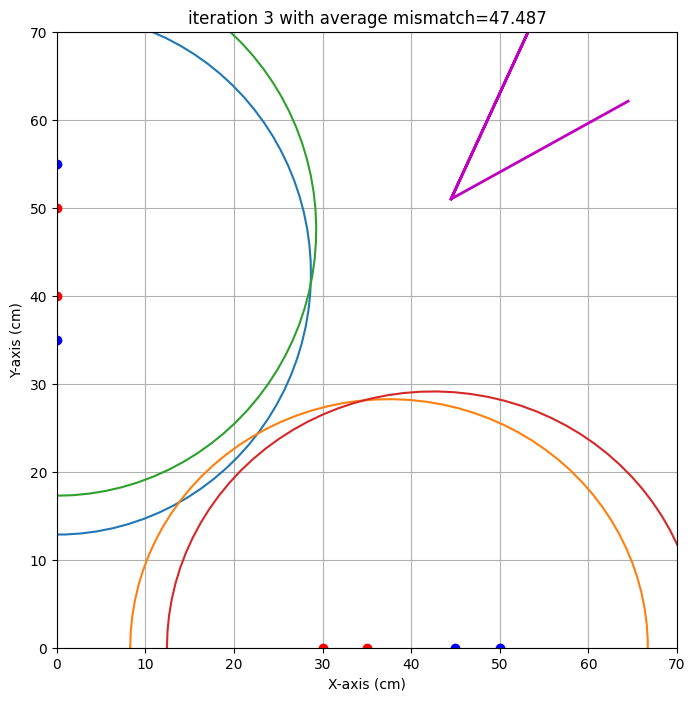

end iteration 3 with average mismatch=47.487


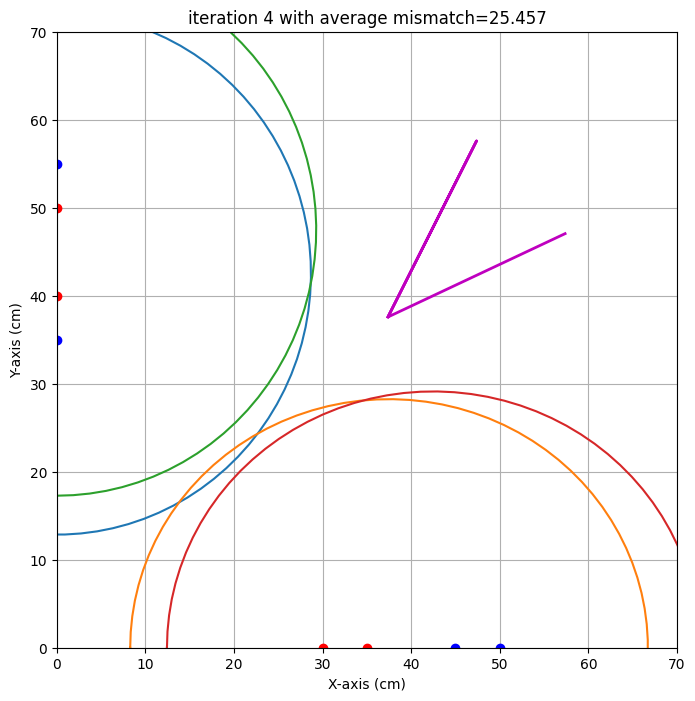

end iteration 4 with average mismatch=25.457


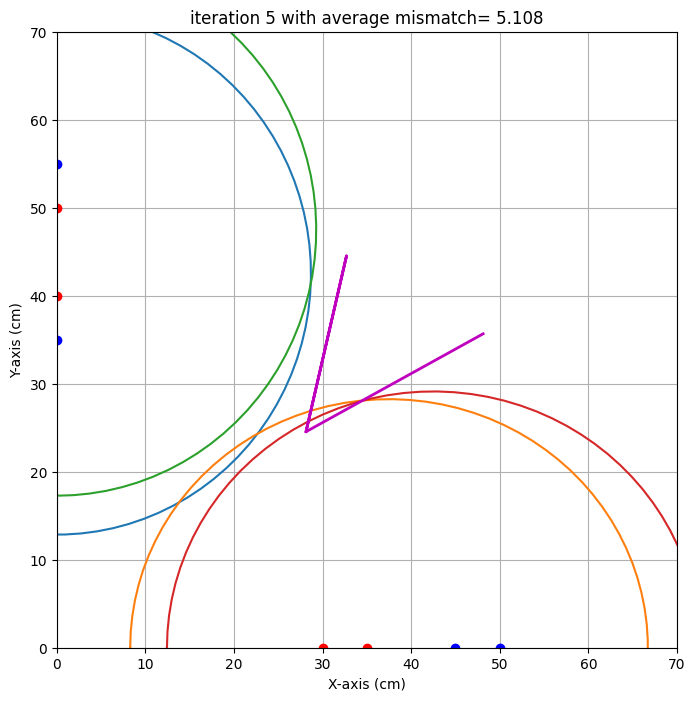

end iteration 5 with average mismatch= 5.108


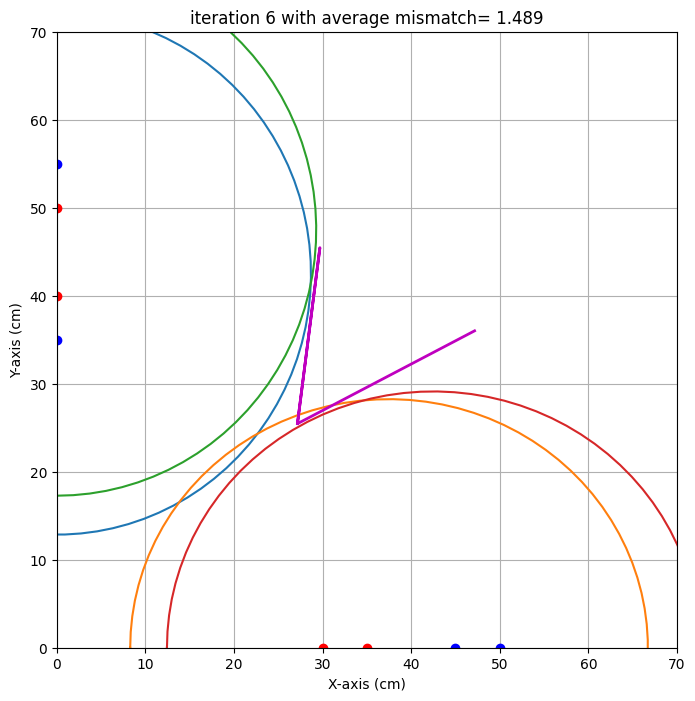

end iteration 6 with average mismatch= 1.489


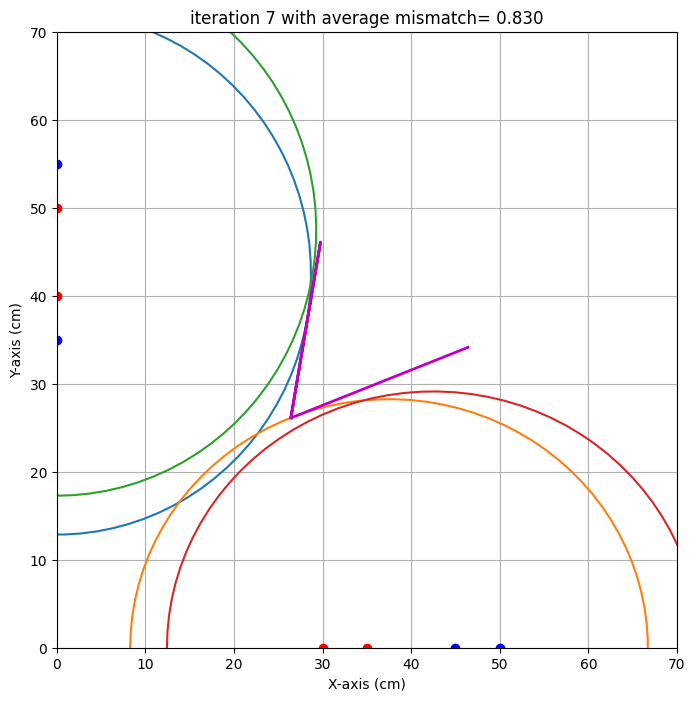

end iteration 7 with average mismatch= 0.830
end iteration 8 with average mismatch= 0.830
end iteration 9 with average mismatch= 0.749


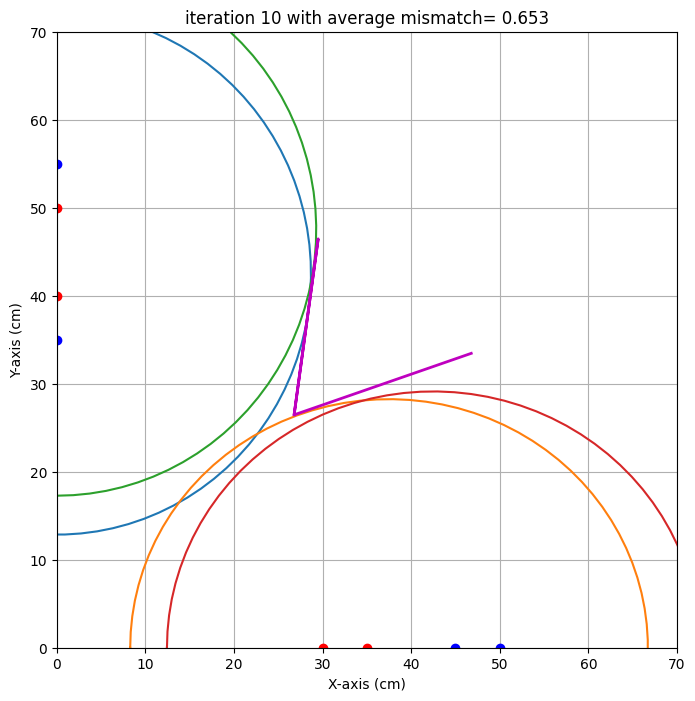

end iteration 10 with average mismatch= 0.653


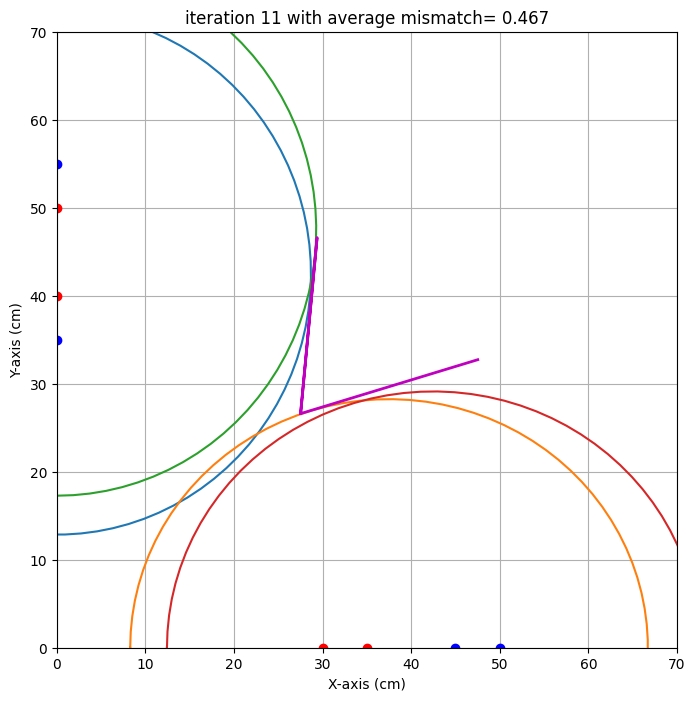

end iteration 11 with average mismatch= 0.467
end iteration 12 with average mismatch= 0.421
end iteration 13 with average mismatch= 0.415
end iteration 14 with average mismatch= 0.415
end iteration 15 with average mismatch= 0.415
end iteration 16 with average mismatch= 0.415
end iteration 17 with average mismatch= 0.415
end iteration 18 with average mismatch= 0.415
end iteration 19 with average mismatch= 0.415
end iteration 20 with average mismatch= 0.415
end iteration 21 with average mismatch= 0.415
end iteration 22 with average mismatch= 0.415
end iteration 23 with average mismatch= 0.415
end iteration 24 with average mismatch= 0.415
end iteration 25 with average mismatch= 0.378
end iteration 26 with average mismatch= 0.378


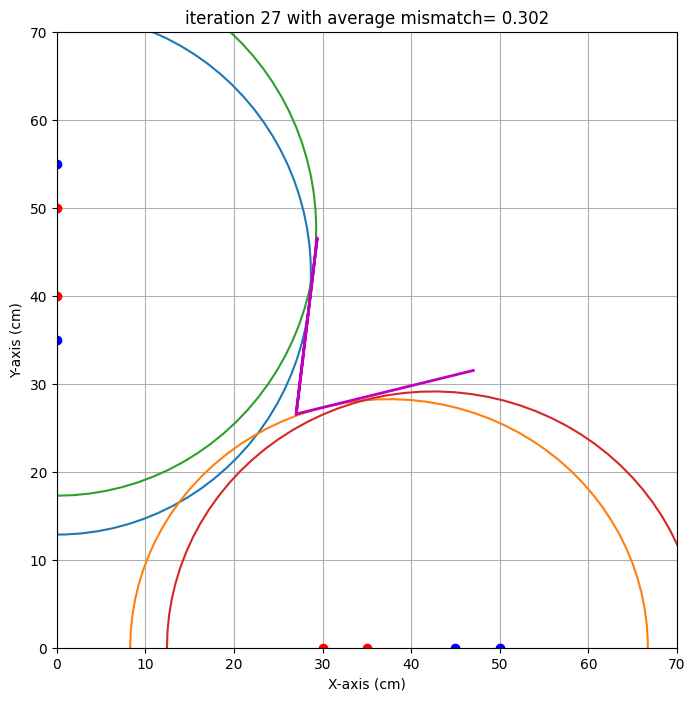

end iteration 27 with average mismatch= 0.302
end iteration 28 with average mismatch= 0.295
end iteration 29 with average mismatch= 0.294
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.294
###############################################################################
end of iteration  30
Best alpha=  13.91 with uncertainty=   1.59
Best beta =   6.77 with uncertainty=   4.20
Best x0   =  27.01 with uncertainty=   0.88
Best y0   =  26.55 with uncertainty=   0.24
###############################################################################


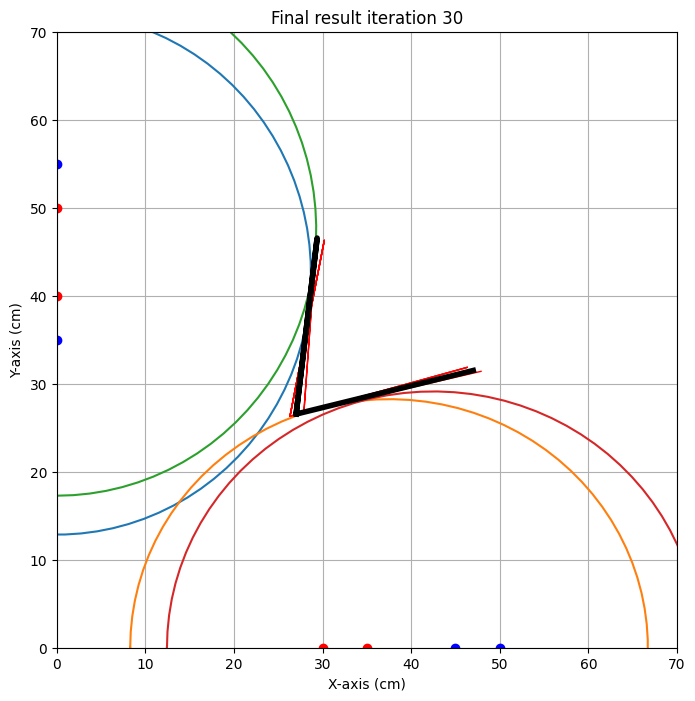

{'alpha': np.float64(13.908284595130457), 'alpha_eps': np.float64(1.592307810220083), 'beta': np.float64(6.773205211379789), 'beta_eps': np.float64(4.1965754830706565), 'x0': np.float64(27.005858255021586), 'x0_eps': np.float64(0.8771352200117448), 'y0': np.float64(26.550455468604596), 'y0_eps': np.float64(0.24223858170148915)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  50   0  35  49.17
1   0  50   0  40  49.45
2  40   0  55   0  86.70
3  35   0  50   0  86.35


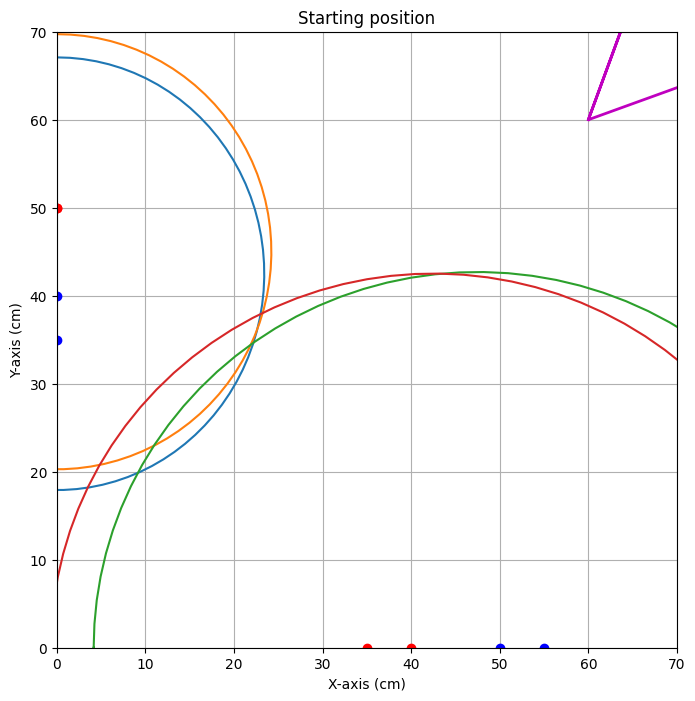


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.422


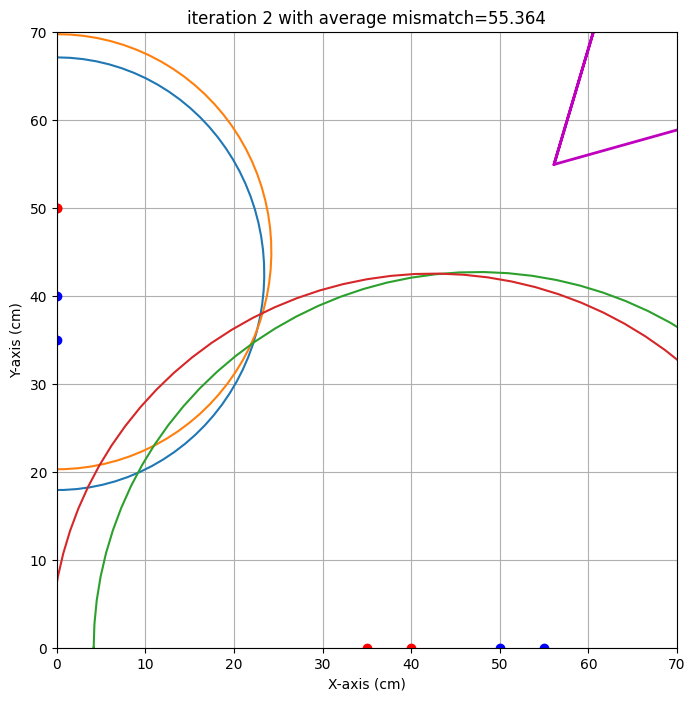

end iteration 2 with average mismatch=55.364


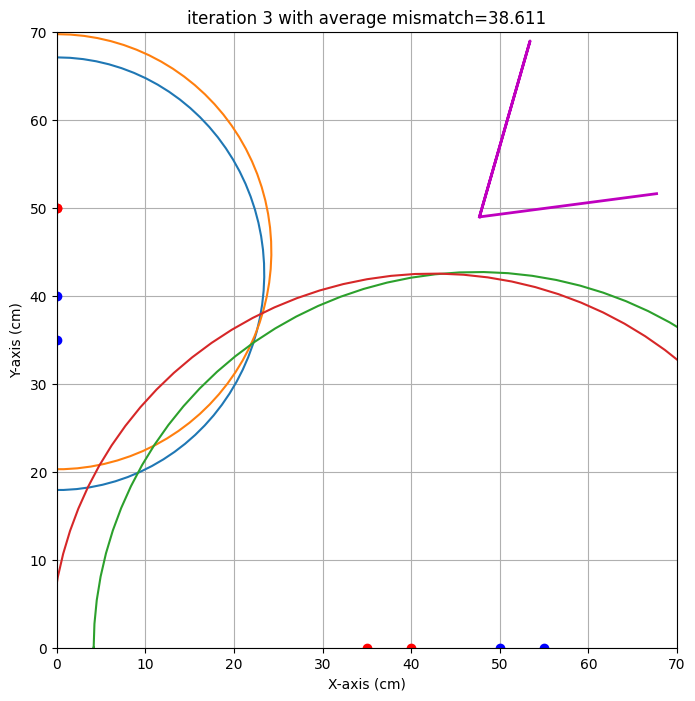

end iteration 3 with average mismatch=38.611


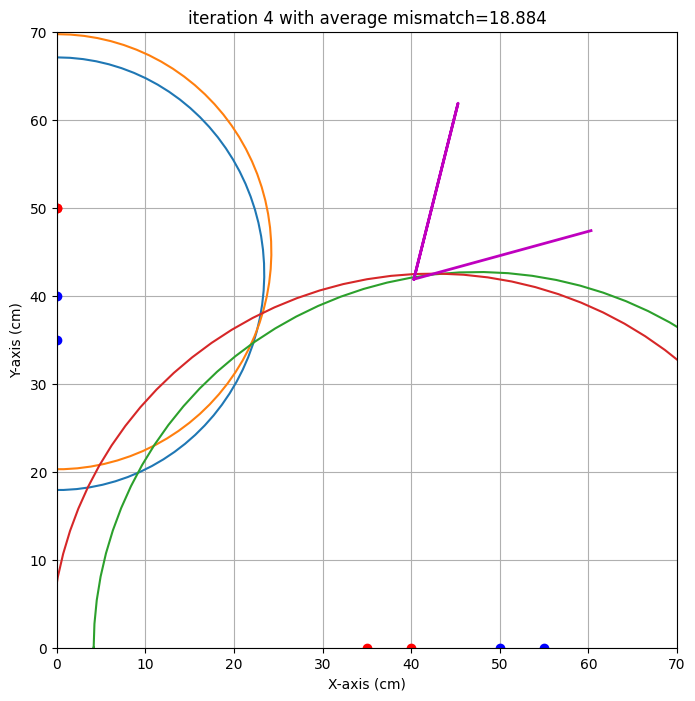

end iteration 4 with average mismatch=18.884


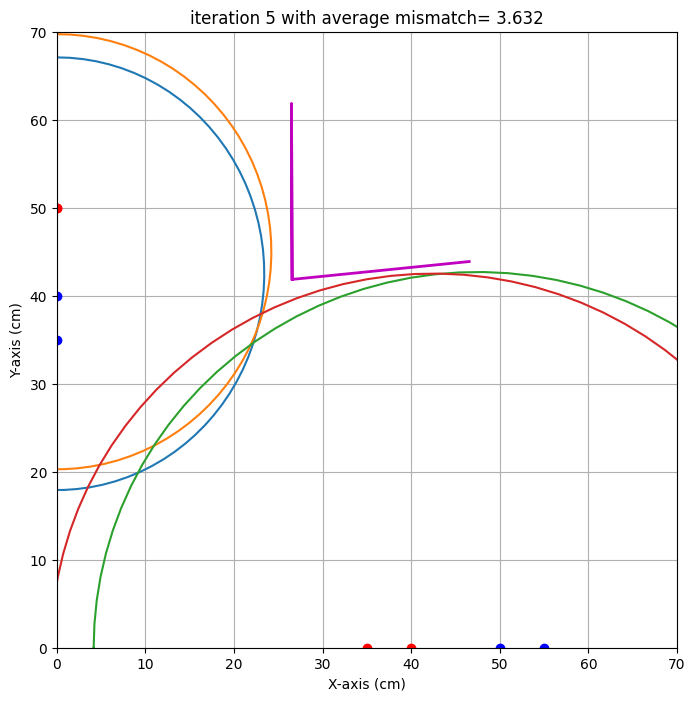

end iteration 5 with average mismatch= 3.632


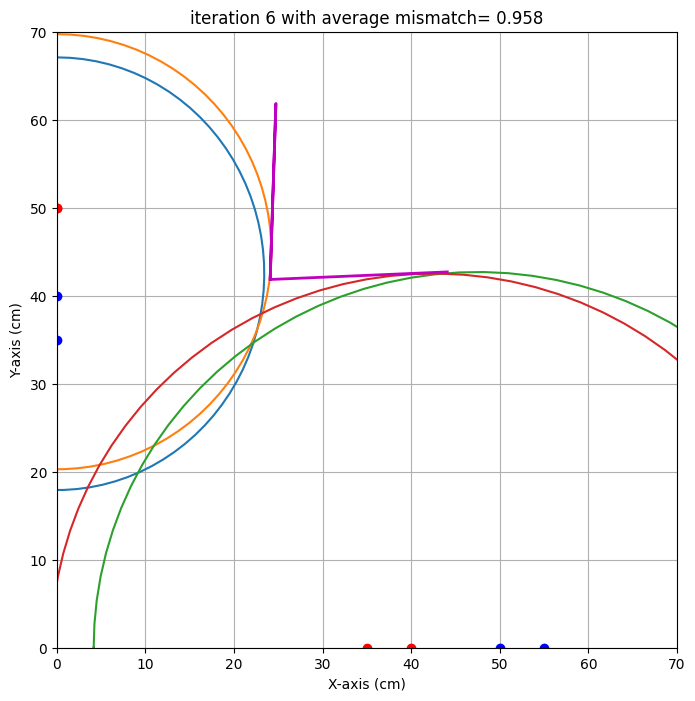

end iteration 6 with average mismatch= 0.958


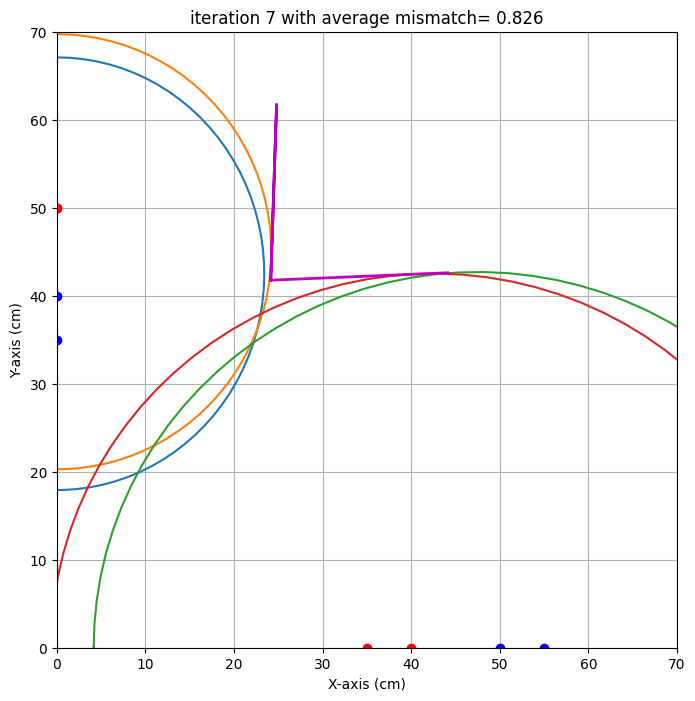

end iteration 7 with average mismatch= 0.826
end iteration 8 with average mismatch= 0.798
end iteration 9 with average mismatch= 0.786
end iteration 10 with average mismatch= 0.748
end iteration 11 with average mismatch= 0.747
end iteration 12 with average mismatch= 0.737
end iteration 13 with average mismatch= 0.735
end iteration 14 with average mismatch= 0.735
end iteration 15 with average mismatch= 0.727


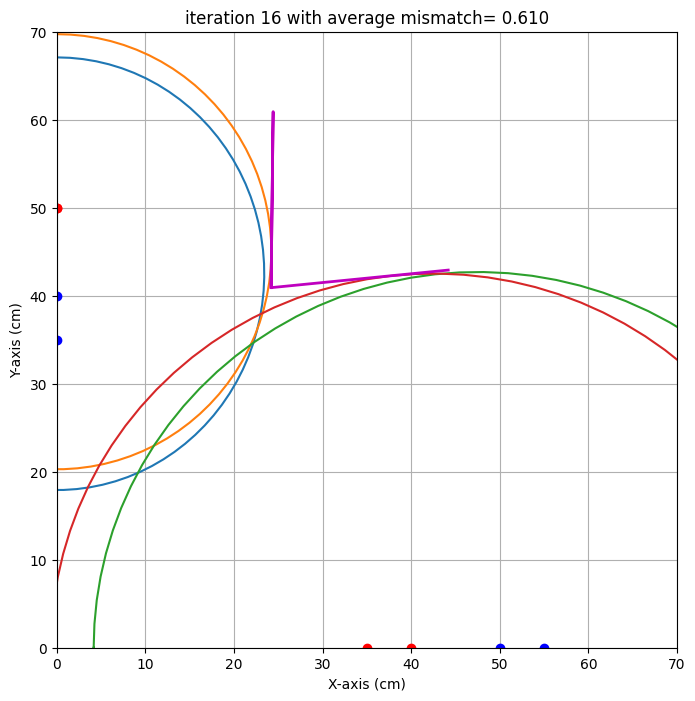

end iteration 16 with average mismatch= 0.610
end iteration 17 with average mismatch= 0.588
end iteration 18 with average mismatch= 0.584
end iteration 19 with average mismatch= 0.584
end iteration 20 with average mismatch= 0.584
end iteration 21 with average mismatch= 0.584
end iteration 22 with average mismatch= 0.584
end iteration 23 with average mismatch= 0.584
end iteration 24 with average mismatch= 0.584
end iteration 25 with average mismatch= 0.584
end iteration 26 with average mismatch= 0.584
end iteration 27 with average mismatch= 0.584
end iteration 28 with average mismatch= 0.584
end iteration 29 with average mismatch= 0.584
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.584
###############################################################################
end of iteration  30
Best alpha=   5.69 with uncertainty=   5.64
Best beta =   0.67 with uncertainty=   5.54
Best x0   = 

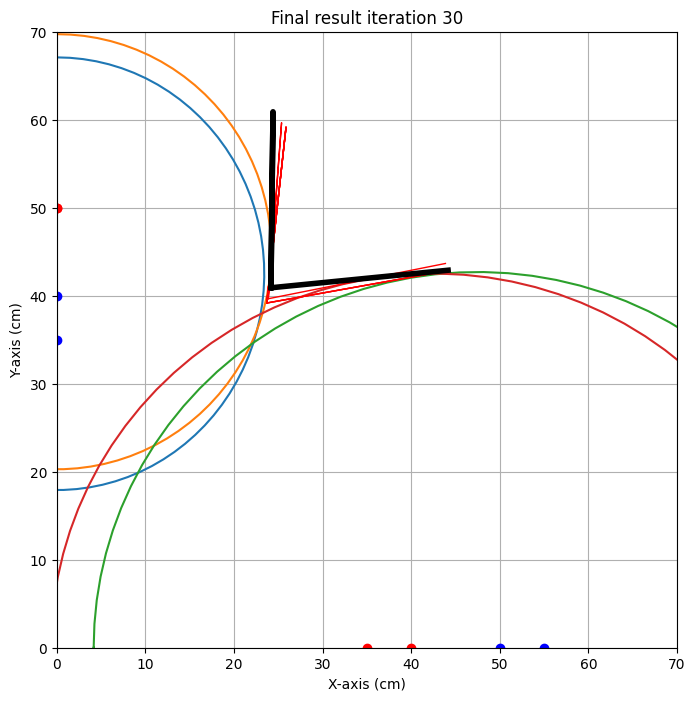

{'alpha': np.float64(5.687282173545828), 'alpha_eps': np.float64(5.640101167296747), 'beta': np.float64(0.6652895813036358), 'beta_eps': np.float64(5.543453936514794), 'x0': np.float64(24.166300468300523), 'x0_eps': np.float64(0.4724125236316752), 'y0': np.float64(40.90393271433014), 'y0_eps': np.float64(1.7327703724472627)}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 27.0 cm met een standaardafwijking van 0.9 cm 
y0 target is : 30.0. Gevonden waarde: 26.6 cm met een standaardafwijking van 0.2 cm 
alpha target is : 15.0. Gevonden waarde: 13.9 graden met een standaardafwijking van 1.6 graad 
beta target is : 15.0. Gevonden waarde: 6.8 graden met een standaardafwijking van 4.2 graad 

locatie 2 
x0 target is : 32.0. Gevonden waarde: 24.2 cm met een standaardafwijking van 0.5 cm 
y0 target is : 19.0. Gevonden waarde: 40.9 cm met een standaardafwijking van 1.7 cm 
alpha target is : 45.0. Gevonden waarde: 5.7 graden met een standaardafwijking van 5.6 graad 
beta target is : 10.0. Gevon

In [13]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':24,#zelf aanvullen,
                    'y0':30,#zelf aanvullen,
                    'alpha' :15, #zelf aanvullen,
                    'beta' : 15},
           'locatie 2':{'x0': 32 ,#zelf aanvullen,
                    'y0': 19 ,#zelf aanvullen,
                    'alpha' :   45,#zelf aanvullen,
                    'beta' :   10,#zelf aanvullen}
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0, 35 ,59.3],
    [30,0, 45, 0, 58.45],
    #[0,5,0, 20, ongeldig],
    #[0, 55, 0,70, ongeldig],
    [0,40,0, 55, 60.45],
    [35,0, 50,0, 60.15]]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,50,0,35,49.17],
    [0,50,0,40, 49.45],
    #[30,0,45,0, ongeldig],
    [40,0,55,0,86.7],
    [35,0,50,0,86.35],
    ])
      }

                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Figuur: ![Alt](iteratie2_laatsteverbetering.png "Title")

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  35   0  50  49.50
1   0  40   0  55  52.00
2  30   0  45   0  49.45
3  35   0  50   0  49.65


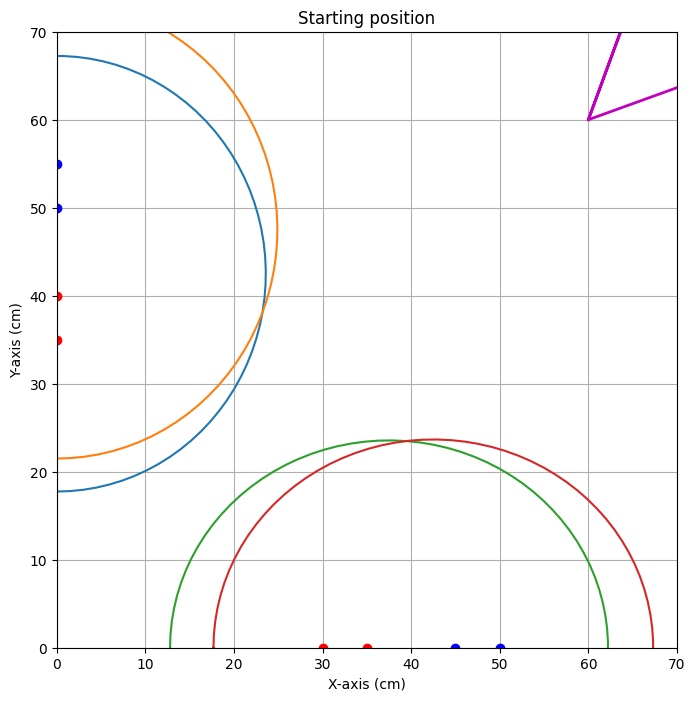


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=82.285


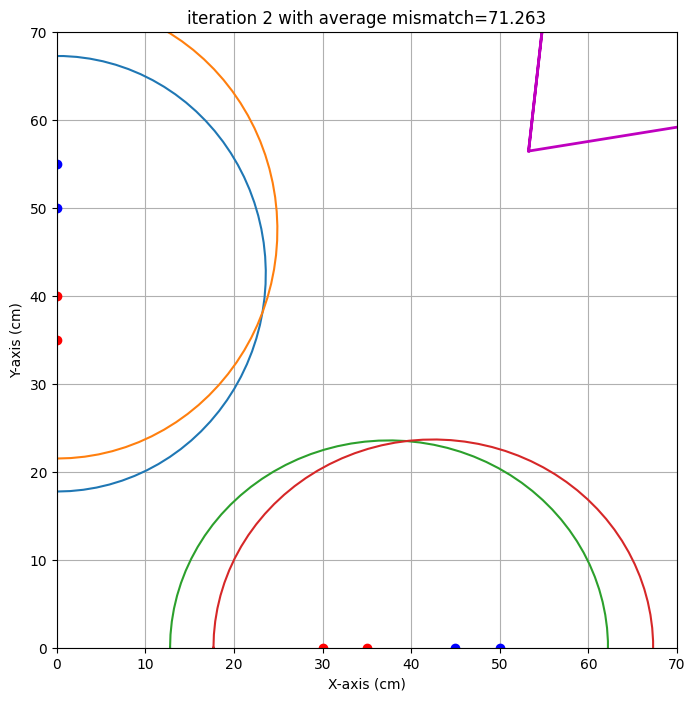

end iteration 2 with average mismatch=71.263


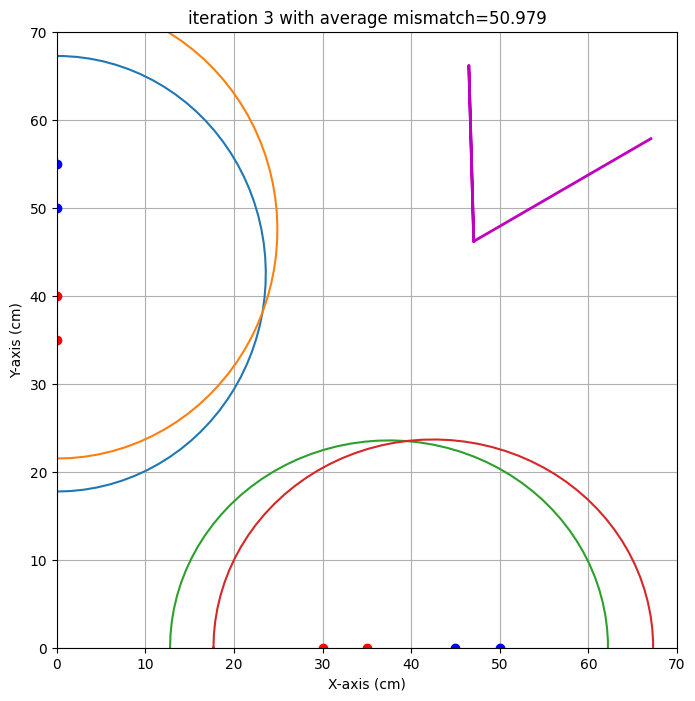

end iteration 3 with average mismatch=50.979


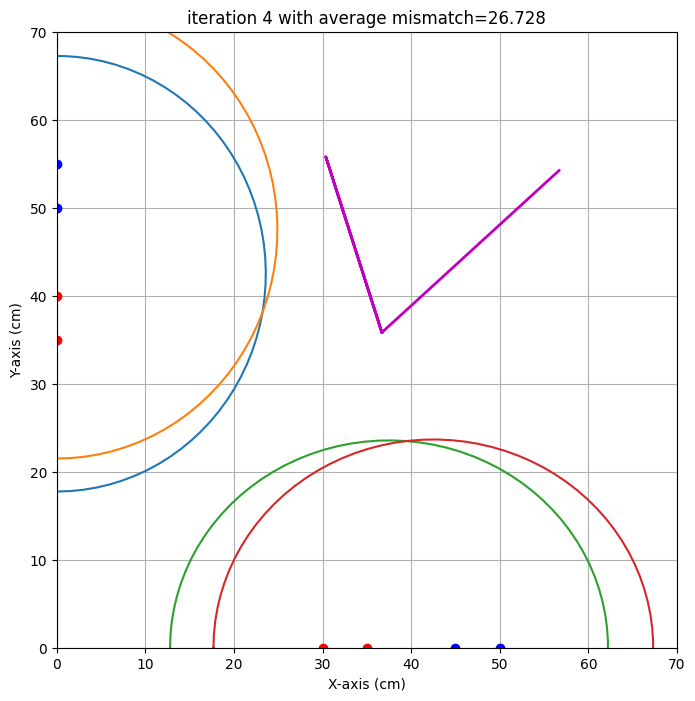

end iteration 4 with average mismatch=26.728


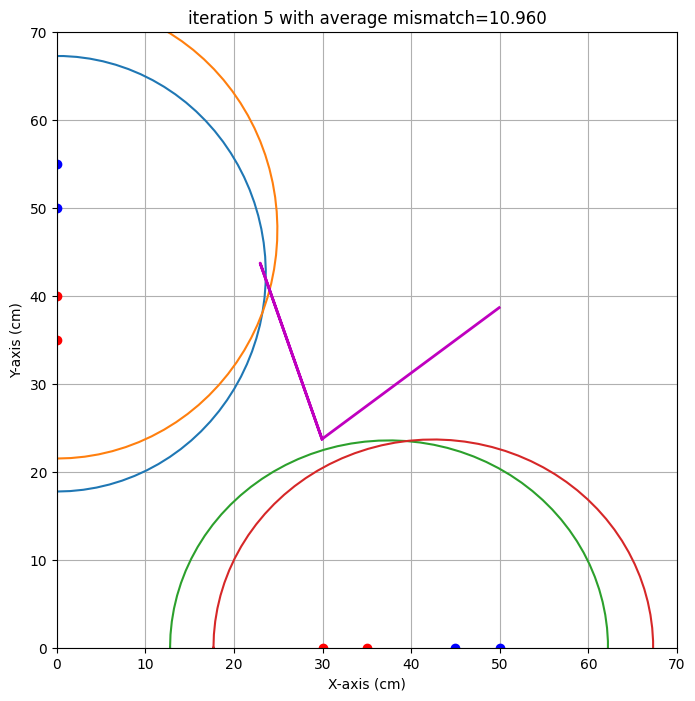

end iteration 5 with average mismatch=10.960


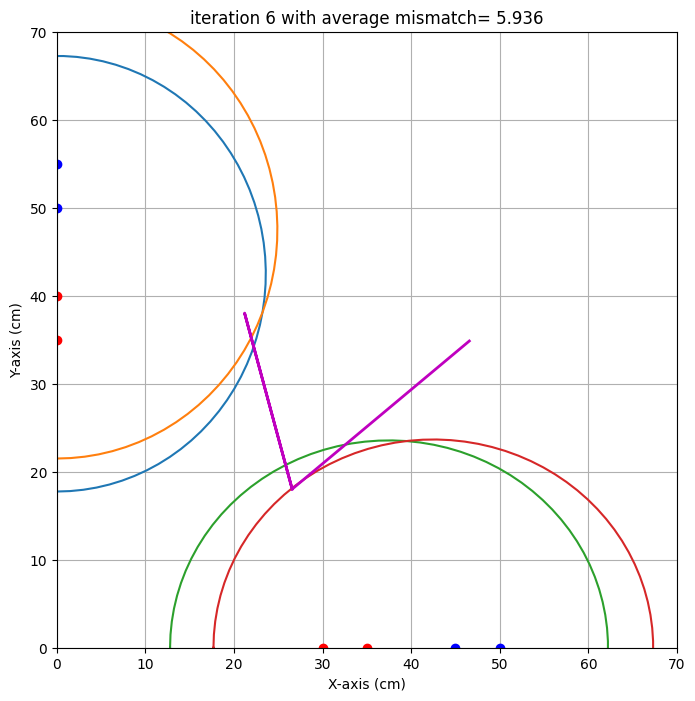

end iteration 6 with average mismatch= 5.936


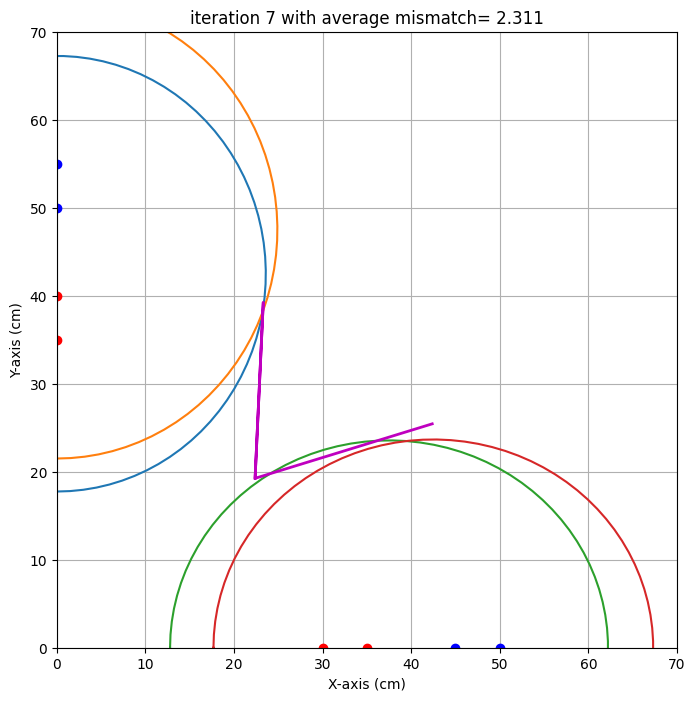

end iteration 7 with average mismatch= 2.311


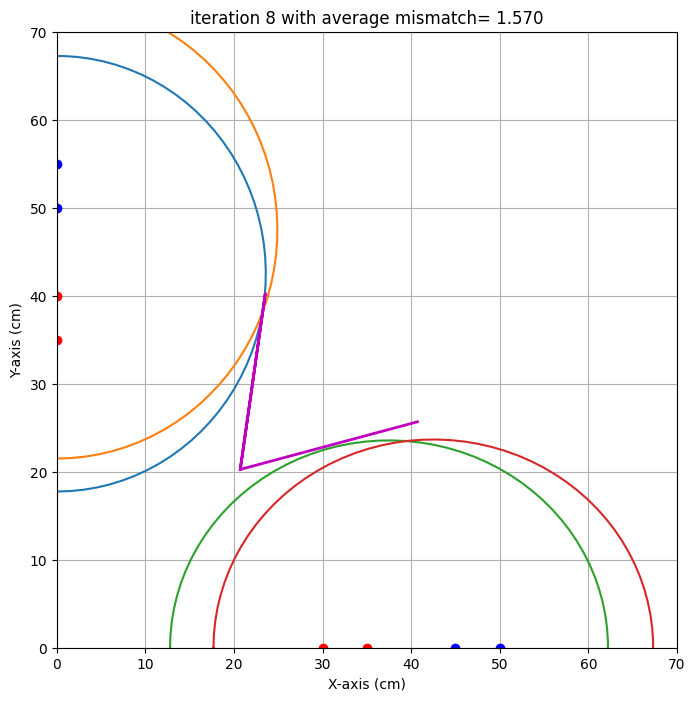

end iteration 8 with average mismatch= 1.570


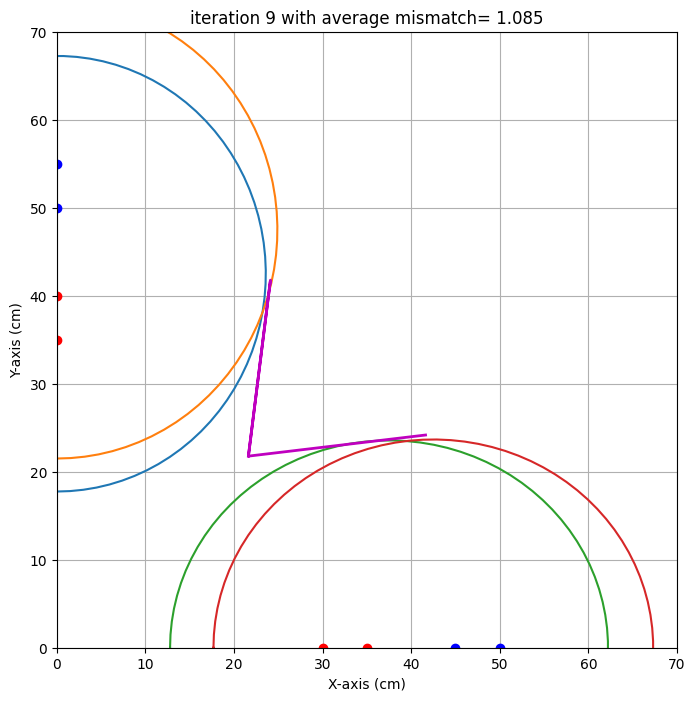

end iteration 9 with average mismatch= 1.085


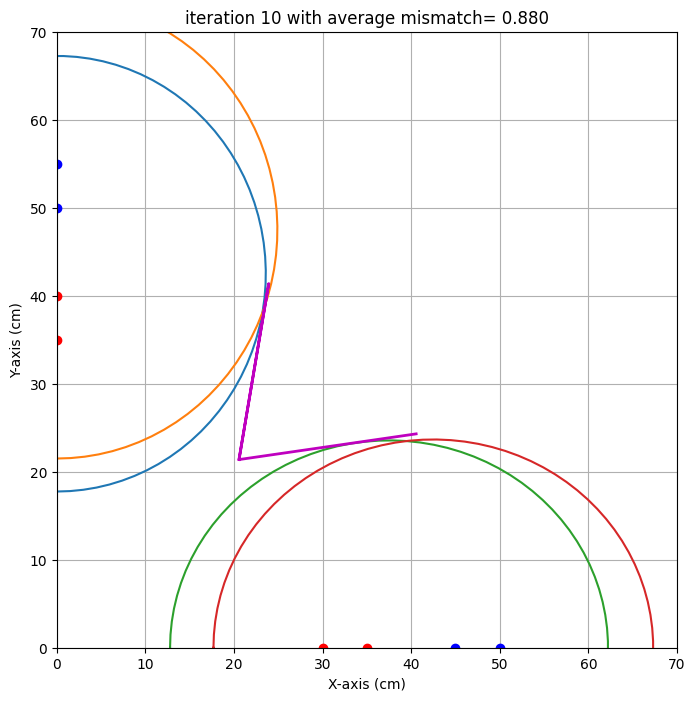

end iteration 10 with average mismatch= 0.880


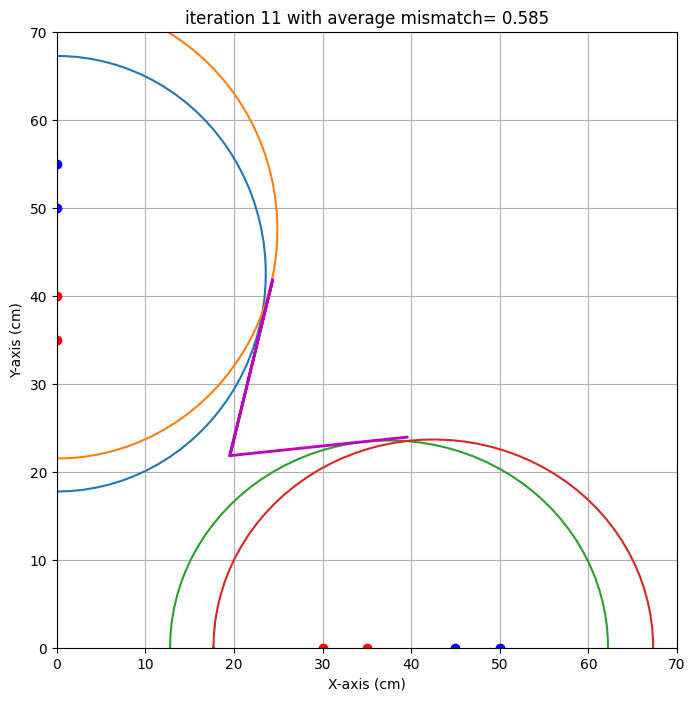

end iteration 11 with average mismatch= 0.585
end iteration 12 with average mismatch= 0.544
end iteration 13 with average mismatch= 0.501
end iteration 14 with average mismatch= 0.491
end iteration 15 with average mismatch= 0.490
end iteration 16 with average mismatch= 0.490
end iteration 17 with average mismatch= 0.490
end iteration 18 with average mismatch= 0.490
end iteration 19 with average mismatch= 0.490
end iteration 20 with average mismatch= 0.490
end iteration 21 with average mismatch= 0.490
end iteration 22 with average mismatch= 0.490
end iteration 23 with average mismatch= 0.490
end iteration 24 with average mismatch= 0.490
end iteration 25 with average mismatch= 0.490
end iteration 26 with average mismatch= 0.490
end iteration 27 with average mismatch= 0.490
end iteration 28 with average mismatch= 0.490
end iteration 29 with average mismatch= 0.490
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

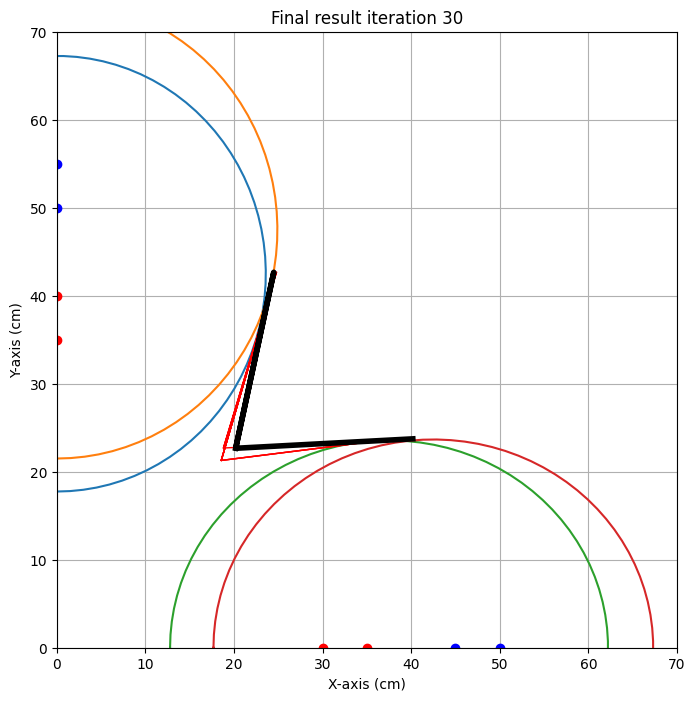

{'alpha': np.float64(3.0673906316620068), 'alpha_eps': np.float64(4.1385655329476725), 'beta': np.float64(12.13887907852051), 'beta_eps': np.float64(4.575561611565629), 'x0': np.float64(20.184285450879123), 'x0_eps': np.float64(1.6291738065155954), 'y0': np.float64(22.66519599738349), 'y0_eps': np.float64(1.382593833207359)}
test locatie 
x0 target is : 21.0. Gevonden waarde: 20.2 cm met een standaardafwijking van 1.6 cm 
y0 target is : 20.0. Gevonden waarde: 22.7 cm met een standaardafwijking van 1.4 cm 
alpha target is : 11.0. Gevonden waarde: 3.1 graden met een standaardafwijking van 4.1 graad 
beta target is : 9.0. Gevonden waarde: 12.1 graden met een standaardafwijking van 4.6 graad 



In [14]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 21, # zelf aanvullen,
                    'y0':  20,# zelf aanvullen,
                    'alpha' :  11,# zelf aanvullen,
                    'beta' : 9 # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [0,35,0, 50 ,49.50],
                    [0,40,0, 55 ,52.00],
                    [30,0,45,0, 49.45],
                    [35,0,50,0,49.65]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Naar aanleiding van de feedback:
We hebben gekeken naar de oorzaak van de afwijking (oplopend tot +-3.5 cm) op onze berekende $y_0$-coördinaat. Dit verschil is eigenlijk een direct gevolg van de keuzes in ons experimenteel ontwerp.Ons hoofddoel was namelijk om de locatie en hoeken van het papier te bepalen met zo min mogelijk metingen. We hebben het systeem geminimaliseerd tot exact vier metingen om onze vier onbekenden ($x_0$, $y_0$, $\alpha$ en $\beta$) op te lossen. Omdat we hierdoor geen overtollige data hebben verzameld, is er geen wiskundige hulp voor het algoritme om de aanwezige meetruis uit te middelen. Elke kleine meetfout tikt dus ongedempt door in het eindresultaat. In onze situatie komt deze afwijking waarschijnlijk door een paar imperfecties tijdens het meten. Denk hierbij aan een lichte rotatie van de zender of ontvanger (bewust voor een stabielere meting), of een kleine onnauwkeurigheid bij het handmatig uitlijnen van de sensoren recht boven de liniaal. Daarnaast is de knik in het reflecterende papier in de realiteit natuurlijk iets afgerond en geen perfect scherpe wiskundige hoek. Door onze minimalistische, foutgevoelige dataset vertalen dit soort kleine foutjes zich direct in een grotere ruimtelijke onzekerheid, wat logischerwijs verklaart waarom de afwijking voor $y_0$ groter is dan 1 cm.
En zoals gezegd is de afwijking anders nadat elke keer de code opnieuw wordt gerund, waaruit blijkt dat het algoritme ''imagingDEF'' simpelweg geen perfecte oplossing kán vastpinnen en daardoor telkens een iets andere aanname doet.

## Opdracht 11: Leerdoelen.
Het algoritme met zijn verbeteringen is hieronder weergegeven in drie versies:


<img src="fototahlia.png" width="400">
Begin met het meten in de midde met allebei de sensoren 15 cm van elkaar af. Als een van de twee metingen iets op pakt, schuif de sensoren dan een stukje op en meet opnieuw. Als beide nika op pakt, zet de sneoren weer pp de y-as dichtbij de origin en meet opnieuw, en dan op de x-as ver weg van de origin en maak nog een meting. als de laatste twee metingen ook iets oppakken beweeg ze een klein beetje en meet opnieuw.
//
<img src="verbeterdalgoritme_iteratie+1.png" width="400">

 Deze eerste versie werkte niet omdat als de sensoren dichtbij en verweg van de origin zaten dan missen we een hele hoek van het opppervlak. daarom moeten alleen op een as blijven als onze twee middelste metingen niet gelukt zijn.Begin hetzelfde met eerst in de midden van de as meten, maar nu als die iets oppakt beweeg de sensoren 5cm en meet opnieuw, dan ga naar de andere as, meet weer in het midden en als de sensor iets oppakt, schrijf de meting op en beweeg 5cm van het punt vandaan. Als geen van beide midden punten gelukt zijn, blijf dan op een as, meet een keertje dichtbij de origin en een keertje verweg van de origin om het hele oppervlak over te gaan. 

<img src="iteratie2_laatsteverbetering.png" width="400">


Als de middelste twee metingen niet gelukt zijn en je op de rand punten van het as meet, begin dan eerst aan de verste kant en als die lukt beweeg dan 5cm dichterbij. als die niet lukt begin dan dichtbij de orogin, als die gelukt is meet dan 5cm verder op in de positiefe richting. wanneer de middelste metingen lukken beweeg dan ook eerst 5cm in de positiefe richting en als die niet lukken in de negatieve richting. dit is voor consistentie. Dit is een systematische aanpak, waarvoor we uiteindelijk alleen 4 metingen nodig hadden om het object's locatie nauwkeurig te bepalen. 
